# **Analisis Pola Konsumsi Kopi Mahasiswa**

## **Input Data**

In [1]:
from google.colab import files
upload = files.upload()

Saving Jawaban Kuesioner Ngopi.csv to Jawaban Kuesioner Ngopi (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import re

In [3]:
df = pd.read_csv(list(upload.keys())[0])

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 18 columns):
 #   Column                                                                                          Non-Null Count  Dtype 
---  ------                                                                                          --------------  ----- 
 0   Timestamp                                                                                       165 non-null    object
 1   Email Address                                                                                   165 non-null    object
 2   Apakah anda bersedia mengisi pertanyaan-pertanyaan berikut ini?                                 165 non-null    object
 3   Nama                                                                                            165 non-null    object
 4   NPM                                                                                             165 non-null    object
 5   Fakultas              

In [5]:
# RENAME COLUMNS
column_mapping = {
    'Timestamp': 'timestamp',
    'Email Address': 'email',
    'Apakah anda bersedia mengisi pertanyaan-pertanyaan berikut ini?': 'bersedia',
    'Nama': 'nama',
    'NPM': 'npm',
    'Fakultas': 'fakultas',
    'Program Studi': 'prodi',
    'Nomer Whatsapp': 'no_wa',
    'Berapa gelas kopi yang biasanya kamu konsumsi dalam sehari saat kuliah?': 'gelas_per_hari',
    'Berapa rupiah rata-rata yang kamu habiskan untuk membeli kopi dalam seminggu sebagai mahasiswa': 'pengeluaran_mingguan',
    'Berapa jam biasanya kamu bisa bertahan belajar setelah minum kopi?': 'durasi_belajar',
    'Berapa kali dalam seminggu kamu nongkrong atau belajar di kafe?': 'frekuensi_cafe',
    'Berapa persen menurutmu kopi membantu meningkatkan fokus belajar (0–100%)?': 'persen_fokus',
    'Bagaimana cara kamu biasanya mendapatkan kopi? ': 'cara_dapat_kopi',
    'Waktu paling sering kamu minum kopi saat jadi mahasiswa? ': 'waktu_ngopi',
    'Efek utama yang kamu rasakan setelah minum kopi saat belajar? ': 'efek_kopi',
    'Di mana tempat favorit kamu minum kopi sambil belajar? ': 'tempat_favorit',
    'Menurutmu, ngopi sebagai mahasiswa itu lebih ke arah apa?': 'makna_ngopi'
}

## **Cek Missing value**

In [6]:
print("CEK MISSING VALUE")

missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("Tidak ada missing value")
else:
    print(f"Total missing value: {missing_df['Missing Count'].sum()}")

CEK MISSING VALUE
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
Tidak ada missing value


## **Transformasi Data**

In [7]:
print("Transform: Gelas per Hari")

def transform_gelas(value, modus_val=None):
    """Transformasi kolom gelas_per_hari menjadi numerik (integer, no decimal)"""
    if pd.isna(value):
        return np.nan

    val = str(value).strip().lower()

    # Kasus spesial
    if "kadang 1 atau 0" in val:
        return 1.0
    if "tidak menentu" in val:
        return modus_val

    # Kasus nol
    zero_keywords = [
        "noll", "nolll", "aku nyusu", "tidak setiap hari",
        "tidak ada", "seminggu maks satu", "tidak", "minggu", "tidak pernah"
    ]
    if any(kw in val for kw in zero_keywords):
        return 0.0

    # Rentang
    match = re.search(r"(\d+(?:[.,]\d+)?)\s*[-–/]\s*(\d+(?:[.,]\d+)?)", val)
    if match:
        low = float(match.group(1).replace(",", "."))
        high = float(match.group(2).replace(",", "."))
        return round((low + high) / 2.0)

    # Angka tunggal
    nums = re.findall(r"\d+(?:[.,]\d+)?", val)
    if nums:
        return round(float(nums[0].replace(",", ".")))

    return np.nan

# Apply column renaming
df.rename(columns=column_mapping, inplace=True)

# Parse pertama untuk cari modus
temp = df['gelas_per_hari'].apply(lambda x: transform_gelas(x))
modus_val = temp.mode().iloc[0] if not temp.mode().empty else 1

# Parse ulang dengan modus
df['gelas_num'] = df['gelas_per_hari'].apply(lambda x: transform_gelas(x, modus_val))

print(f"Berhasil transform. Modus: {modus_val} gelas")
print(f"Range: {int(df['gelas_num'].min())} - {int(df['gelas_num'].max())} gelas")
print(f"Median: {int(df['gelas_num'].median())} gelas")

Transform: Gelas per Hari
Berhasil transform. Modus: 1.0 gelas
Range: 0 - 8 gelas
Median: 1 gelas


In [8]:
print("Transform: Pengeluaran Mingguan")

def transform_pengeluaran(value):
    """Transformasi pengeluaran menjadi rupiah (numerik)"""
    if isinstance(value, str):
        val = value.strip().lower()

        # Rentang nilai
        if "-" in val:
            nums = re.findall(r"\d+", val)
            if nums:
                nums = [int(x) for x in nums]
                mean_val = np.mean(nums)
                if "rb" in val or "ribu" in val or "k" in val:
                    mean_val *= 1000
                return mean_val

        # Angka tunggal
        nums = re.findall(r"\d+", val)
        if nums:
            angka = int(nums[0])
            if "rb" in val or "ribu" in val or "k" in val:
                angka *= 1000
            return angka

        return np.nan
    return value

df['pengeluaran_num'] = df['pengeluaran_mingguan'].apply(transform_pengeluaran)

print("Berhasil transform")
print(f"Range: Rp {df['pengeluaran_num'].min():,.0f} - Rp {df['pengeluaran_num'].max():,.0f}")
print(f"Mean: Rp {df['pengeluaran_num'].mean():,.0f}")

Transform: Pengeluaran Mingguan
Berhasil transform
Range: Rp 0 - Rp 200,000
Mean: Rp 27,209


In [9]:
print("Transform: Durasi Belajar")

def transform_durasi_belajar(value):
    """Transformasi durasi belajar menjadi jam (numerik)"""
    if pd.isna(value):
        return 0

    val = str(value).lower().strip()

    # Kasus khusus: seharian
    if 'seharian' in val or 'sampai pagi' in val or '24 jam' in val:
        return 24

    # Tidak berpengaruh
    no_effect_keywords = [
        'tidak berpengaruh', 'tidak pengaruh', 'tidak gopi',
        'tidak bisa', 'belum pernah', 'bisa tahan tanpa',
        'gak ngaruh', 'gaperlu'
    ]
    if any(kw in val for kw in no_effect_keywords):
        return 0

    if val == '-' or val == '':
        return 0

    # Extract angka
    numbers = re.findall(r'\d+(?:\.\d+)?', val)
    if len(numbers) == 0:
        if 'tergantung' in val:
            return None
        return 0

    # Rentang
    if len(numbers) >= 2:
        return (float(numbers[0]) + float(numbers[1])) / 2

    return float(numbers[0])

df['durasi_num'] = df['durasi_belajar'].apply(transform_durasi_belajar)

# Fill 'tergantung' dengan mean
mean_durasi = df['durasi_num'].mean()
df['durasi_num'] = df['durasi_num'].fillna(mean_durasi)

print(f"Berhasil transform. Mean untuk nilai 'tergantung': {mean_durasi:.2f} jam")
print(f"Range: {df['durasi_num'].min()} - {df['durasi_num'].max()} jam")
print(f"Median: {df['durasi_num'].median()} jam")

Transform: Durasi Belajar
Berhasil transform. Mean untuk nilai 'tergantung': 3.68 jam
Range: 0.0 - 24.0 jam
Median: 3.0 jam


In [10]:
print("Transform: Frekuensi Cafe")

def transform_frekuensi_cafe(value):
    """Transformasi frekuensi nongkrong di cafe"""
    if pd.isna(value):
        return 0

    val = str(value).lower().strip()

    # Tidak pernah
    never_keywords = [
        'tidak pernah', 'belum pernah', 'hampir tidak pernah',
        'sebulan sekali', 'satu bulan sekali'
    ]
    if any(kw in val for kw in never_keywords):
        return 0

    if val == '-' or val == 'n' or val == '':
        return 0

    # 1 bulan 2 kali = 0.5 per minggu
    if '1 bulan 2 kali' in val or '2 minggu sekali' in val or 'dua minggu sekali' in val:
        return 1

    # Extract angka
    numbers = re.findall(r'\d+', val)
    if len(numbers) == 0:
        if 'jarang' in val:
            return 1
        return 0

    # Rentang
    if len(numbers) >= 2:
        lower = int(numbers[0])
        upper = int(numbers[1])
        if upper <= 2:
            return upper
        else:
            return round((lower + upper) / 2)

    return int(numbers[0])

df['frekuensi_cafe_num'] = df['frekuensi_cafe'].apply(transform_frekuensi_cafe)

print(f"Berhasil transform")
print(f"Range: {df['frekuensi_cafe_num'].min()} - {df['frekuensi_cafe_num'].max()} kali per minggu")
print(f"Median: {df['frekuensi_cafe_num'].median()} kali per minggu")

Transform: Frekuensi Cafe
Berhasil transform
Range: 0 - 7 kali per minggu
Median: 2.0 kali per minggu


In [11]:
print("Transform: Persen Fokus")

def transform_persen_fokus(value):
    """Transformasi persen fokus"""
    if pd.isna(value):
        return 0

    val = str(value).lower().strip()

    # Tidak tahu
    if any(kw in val for kw in ['tidak tahu', 'tidak suka', 'ga suka']):
        return 0

    val = val.replace('%', '').replace('℅', '').strip()
    numbers = re.findall(r'\d+', val)

    if len(numbers) == 0:
        return 0

    # Rentang
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2

    return int(numbers[0])

df['fokus_num'] = df['persen_fokus'].apply(transform_persen_fokus)

print("Berhasil transform")
print(f"Range: {df['fokus_num'].min()}% - {df['fokus_num'].max()}%")
print(f"Mean: {df['fokus_num'].mean():.2f}%")
print(f"Median: {df['fokus_num'].median()}%")

Transform: Persen Fokus
Berhasil transform
Range: 0.0% - 100.0%
Mean: 48.95%
Median: 50.0%


In [12]:
print("PREVIEW HASIL TRANSFORMASI")

cols_original = ['gelas_per_hari', 'pengeluaran_mingguan', 'durasi_belajar',
                 'frekuensi_cafe', 'persen_fokus']
cols_transformed = ['gelas_num', 'pengeluaran_num', 'durasi_num',
                    'frekuensi_cafe_num', 'fokus_num']

preview_df = df[cols_transformed].head(20)
print(preview_df.to_string(index=True))

print("STATISTIK HASIL TRANSFORMASI")
print(df[cols_transformed].describe().T.round(2))

PREVIEW HASIL TRANSFORMASI
    gelas_num  pengeluaran_num  durasi_num  frekuensi_cafe_num  fokus_num
0         1.0          10000.0         3.0                   3       60.0
1         2.0              0.0         2.0                   0        0.0
2         1.0         100000.0         4.0                   4      100.0
3         1.0          30000.0         3.0                   1       50.0
4         1.0          15000.0         4.0                   1       40.0
5         1.0          14000.0         3.0                   2       70.0
6         1.0          90000.0         0.0                   0       30.0
7         0.0              0.0         1.0                   1       40.0
8         1.0          10000.0         3.0                   0       60.0
9         3.0          45000.0        10.0                   3       85.0
10        1.0          10000.0         2.0                   0       20.0
11        2.0          20000.0         4.0                   1       30.0
12        1

In [13]:
print("VALIDASI HASIL TRANSFORMASI")

# Kolom yang sudah ditransformasi
transformed_cols = {
    'Gelas per Hari': 'gelas_num',
    'Pengeluaran': 'pengeluaran_num',
    'Durasi Belajar': 'durasi_num',
    'Frekuensi Cafe': 'frekuensi_cafe_num',
    'Persen Fokus': 'fokus_num'
}

# Cek missing value
validation_df = pd.DataFrame({
    'Variabel': list(transformed_cols.keys()),
    'Total Data': [len(df)] * len(transformed_cols),
    'Valid': [df[col].notnull().sum() for col in transformed_cols.values()],
    'Missing': [df[col].isnull().sum() for col in transformed_cols.values()],
})
validation_df['% Valid'] = (validation_df['Valid'] / validation_df['Total Data'] * 100).round(2)

print("\nHasil Validasi:")
print(validation_df.to_string(index=False))

if validation_df['Missing'].sum() == 0:
    print("\nSemua variabel berhasil ditransform (tidak ada missing values)")
else:
    print(f"\nMasih ada {validation_df['Missing'].sum()} missing values")

VALIDASI HASIL TRANSFORMASI

Hasil Validasi:
      Variabel  Total Data  Valid  Missing  % Valid
Gelas per Hari         165    165        0    100.0
   Pengeluaran         165    165        0    100.0
Durasi Belajar         165    165        0    100.0
Frekuensi Cafe         165    165        0    100.0
  Persen Fokus         165    165        0    100.0

Semua variabel berhasil ditransform (tidak ada missing values)


In [14]:
# Statistik deskriptif
print("\nStatistik Deskriptif Variabel Transformed:")
stats_df = df[list(transformed_cols.values())].describe().T
stats_df.columns = ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']
print(stats_df.round(2))


Statistik Deskriptif Variabel Transformed:
                    Count      Mean       Std  Min      25%      50%      75%  \
gelas_num           165.0      1.24      1.03  0.0      1.0      1.0      1.0   
pengeluaran_num     165.0  27209.09  32737.88  0.0  10000.0  15000.0  30000.0   
durasi_num          165.0      3.68      3.44  0.0      2.0      3.0      4.5   
frekuensi_cafe_num  165.0      1.87      1.43  0.0      1.0      2.0      3.0   
fokus_num           165.0     48.95     25.48  0.0     30.0     50.0     70.0   

                         Max  
gelas_num                8.0  
pengeluaran_num     200000.0  
durasi_num              24.0  
frekuensi_cafe_num       7.0  
fokus_num              100.0  


## **Atasi Outlier**

In [15]:
print("Deteksi Outlier")

numeric_cols = ['gelas_num', 'pengeluaran_num', 'durasi_num', 'frekuensi_cafe_num', 'fokus_num']
col_labels = ['Gelas/Hari', 'Pengeluaran', 'Durasi Belajar', 'Frekuensi Cafe', 'Fokus (%)']

outlier_summary = []
for col, label in zip(numeric_cols, col_labels):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    n_outliers = len(outliers)
    pct = (n_outliers / len(df) * 100)

    outlier_summary.append({
        'Variabel': label,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outliers': n_outliers,
        '% Outliers': pct
    })

    if n_outliers > 0:
        print(f"{label}:")
        print(f"  Normal Range: [{lower:.2f}, {upper:.2f}]")
        print(f"  Outliers: {n_outliers} ({pct:.2f}%)")

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

Deteksi Outlier
Gelas/Hari:
  Normal Range: [1.00, 1.00]
  Outliers: 58 (35.15%)
Pengeluaran:
  Normal Range: [-20000.00, 60000.00]
  Outliers: 15 (9.09%)
Durasi Belajar:
  Normal Range: [-1.75, 8.25]
  Outliers: 6 (3.64%)
Frekuensi Cafe:
  Normal Range: [-2.00, 6.00]
  Outliers: 2 (1.21%)
      Variabel  Lower Bound  Upper Bound  Outliers  % Outliers
    Gelas/Hari         1.00         1.00        58   35.151515
   Pengeluaran    -20000.00     60000.00        15    9.090909
Durasi Belajar        -1.75         8.25         6    3.636364
Frekuensi Cafe        -2.00         6.00         2    1.212121
     Fokus (%)       -30.00       130.00         0    0.000000


In [16]:
print("Penanganan Outlier")

# Gelas per Hari: Cap di 4 gelas
n_capped_gelas = (df['gelas_num'] > 4).sum()
df['gelas_num'] = df['gelas_num'].clip(upper=4)
print(f"Gelas per Hari: {n_capped_gelas} nilai di-cap pada 4 gelas")

# Pengeluaran: Cap pada persentil 95
pengeluaran_cap = df['pengeluaran_num'].quantile(0.95)
n_capped_pengeluaran = (df['pengeluaran_num'] > pengeluaran_cap).sum()
df['pengeluaran_num'] = df['pengeluaran_num'].clip(upper=pengeluaran_cap)
print(f"Pengeluaran: {n_capped_pengeluaran} nilai di-cap pada Rp {pengeluaran_cap:,.0f}")

# Durasi Belajar: Cap di 10 jam
n_capped_durasi = (df['durasi_num'] > 10).sum()
df['durasi_num'] = df['durasi_num'].clip(upper=10)
print(f"Durasi Belajar: {n_capped_durasi} nilai di-cap pada 10 jam")

# Frekuensi Cafe: Dibiarkan (data valid)
print(f"Frekuensi Cafe & Fokus: Dibiarkan (data valid)")

print("Ringkasan Setelah Treatment:")
print(f"  Gelas per Hari: {int(df['gelas_num'].min())} - {int(df['gelas_num'].max())} gelas")
print(f"  Pengeluaran: Rp {df['pengeluaran_num'].min():,.0f} - Rp {df['pengeluaran_num'].max():,.0f}")
print(f"  Durasi Belajar: {df['durasi_num'].min()} - {df['durasi_num'].max()} jam")

Penanganan Outlier
Gelas per Hari: 2 nilai di-cap pada 4 gelas
Pengeluaran: 5 nilai di-cap pada Rp 100,000
Durasi Belajar: 4 nilai di-cap pada 10 jam
Frekuensi Cafe & Fokus: Dibiarkan (data valid)
Ringkasan Setelah Treatment:
  Gelas per Hari: 0 - 4 gelas
  Pengeluaran: Rp 0 - Rp 100,000
  Durasi Belajar: 0.0 - 10.0 jam


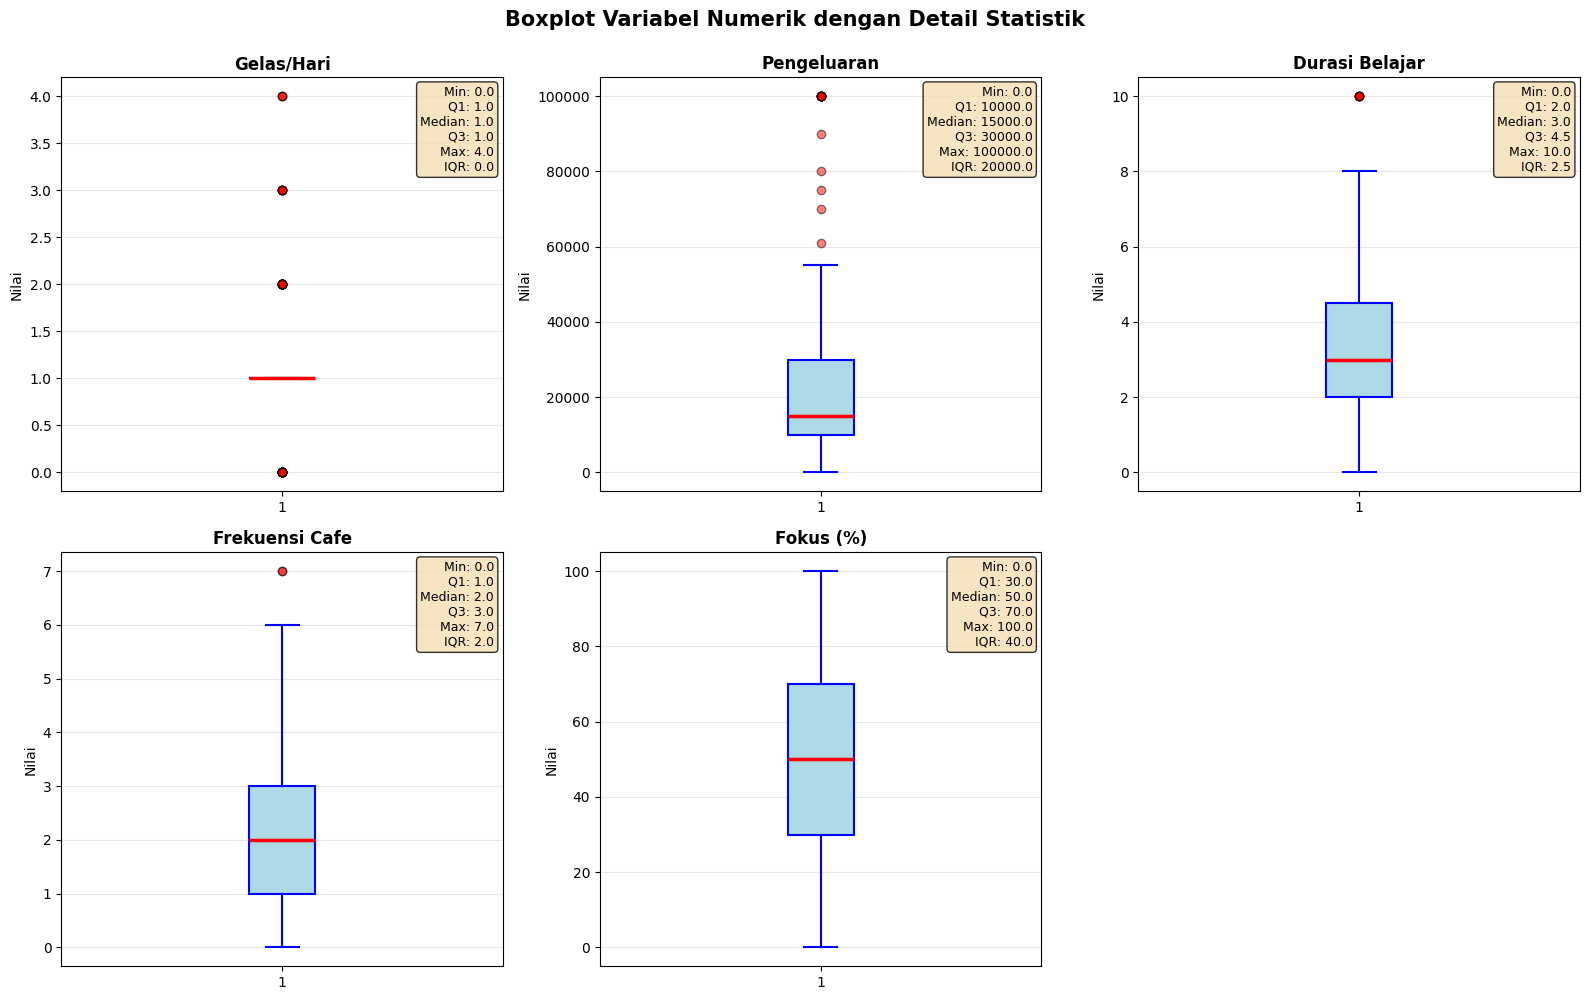

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (col, label) in enumerate(zip(numeric_cols, col_labels)):
    ax = axes[idx]

    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='blue', linewidth=1.5),
                    medianprops=dict(color='red', linewidth=2.5),
                    whiskerprops=dict(color='blue', linewidth=1.5),
                    capprops=dict(color='blue', linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                   markersize=6, alpha=0.5))

    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_ylabel('Nilai')
    ax.grid(True, alpha=0.3, axis='y')

    # Statistik lengkap
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].median()
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    min_val = df[col].min()
    max_val = df[col].max()

    stats_text = f'Min: {min_val:.1f}\nQ1: {Q1:.1f}\nMedian: {Q2:.1f}\n'
    stats_text += f'Q3: {Q3:.1f}\nMax: {max_val:.1f}\nIQR: {IQR:.1f}'

    ax.text(0.98, 0.98, stats_text,
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

axes[-1].axis('off')
plt.suptitle('Boxplot Variabel Numerik dengan Detail Statistik',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## **Visualisasi Data**

In [18]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

VISUALISASI VARIABEL NUMERIK


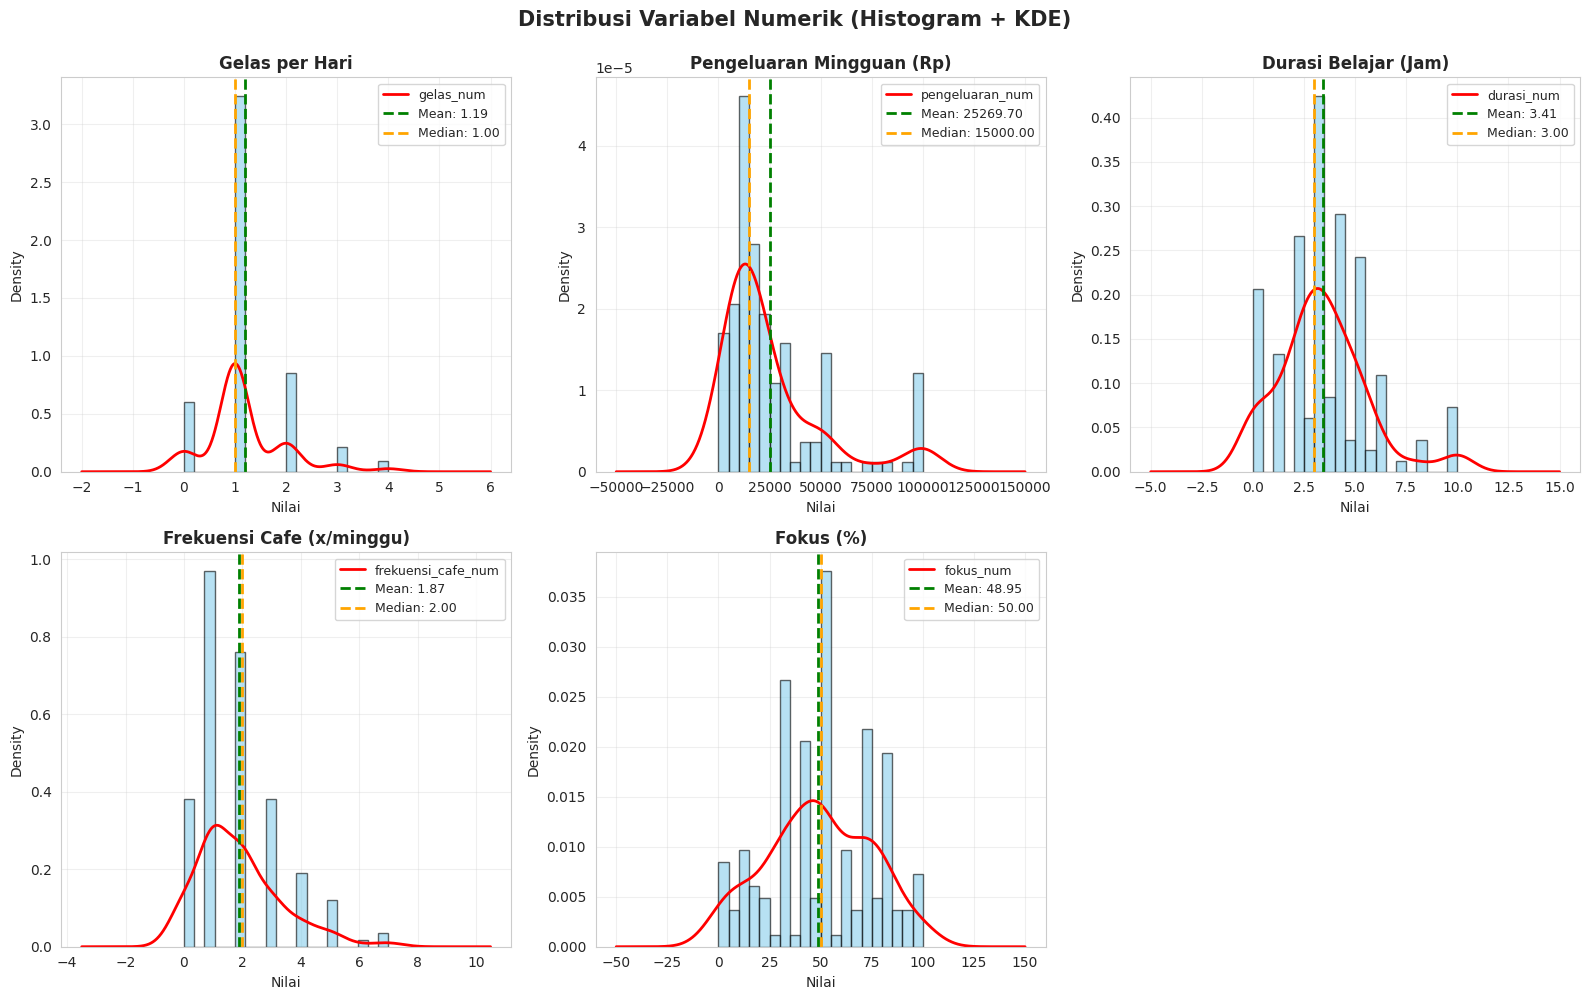

In [19]:
print("VISUALISASI VARIABEL NUMERIK")

numeric_cols = ['gelas_num', 'pengeluaran_num', 'durasi_num',
                'frekuensi_cafe_num', 'fokus_num']
col_labels = ['Gelas per Hari', 'Pengeluaran Mingguan (Rp)',
              'Durasi Belajar (Jam)', 'Frekuensi Cafe (x/minggu)',
              'Fokus (%)']

# HISTOGRAM + KDE
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (col, label) in enumerate(zip(numeric_cols, col_labels)):
    ax = axes[idx]

    # Histogram
    ax.hist(df[col], bins=20, alpha=0.6, color='skyblue',
            edgecolor='black', density=True)

    # KDE
    df[col].plot(kind='kde', ax=ax, color='red', linewidth=2)

    # Statistik
    mean_val = df[col].mean()
    median_val = df[col].median()

    ax.axvline(mean_val, color='green', linestyle='--', linewidth=2,
               label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2,
               label=f'Median: {median_val:.2f}')

    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Distribusi Variabel Numerik (Histogram + KDE)',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

Heatmap Korelasi


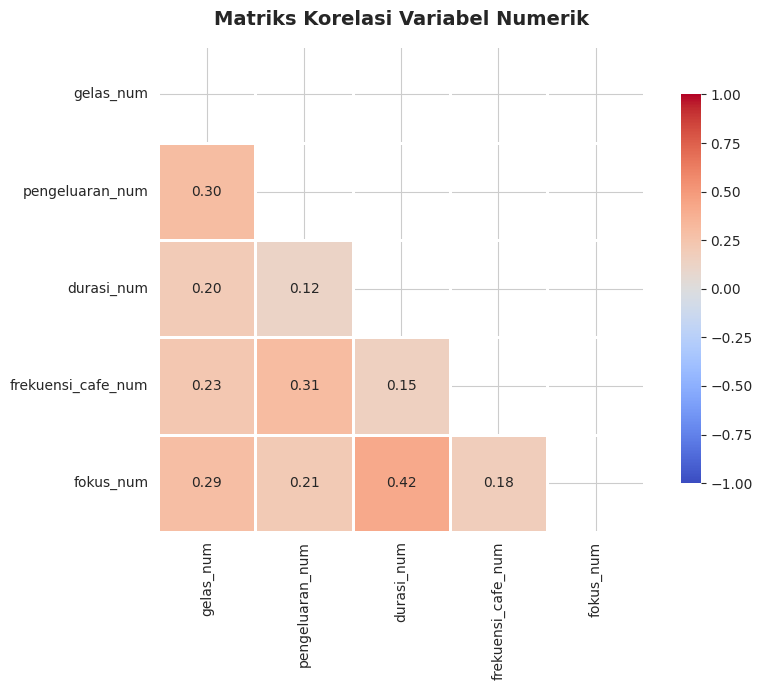

Korelasi Tertinggi:
                     Var1                      Var2  Korelasi
     Durasi Belajar (Jam)                 Fokus (%)  0.416373
Pengeluaran Mingguan (Rp) Frekuensi Cafe (x/minggu)  0.311620
           Gelas per Hari Pengeluaran Mingguan (Rp)  0.299244
           Gelas per Hari                 Fokus (%)  0.289863
           Gelas per Hari Frekuensi Cafe (x/minggu)  0.232020


In [20]:
print("Heatmap Korelasi")

plt.figure(figsize=(9, 7))
correlation_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            mask=mask, vmin=-1, vmax=1)

plt.title('Matriks Korelasi Variabel Numerik', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print korelasi tertinggi
print("Korelasi Tertinggi:")
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Var1': col_labels[i],
            'Var2': col_labels[j],
            'Korelasi': correlation_matrix.iloc[i, j]
        })
corr_df = pd.DataFrame(corr_pairs).sort_values('Korelasi',
                                                 key=abs,
                                                 ascending=False)
print(corr_df.head(5).to_string(index=False))

Pairplot untuk melihat relasi antar variabel numerik


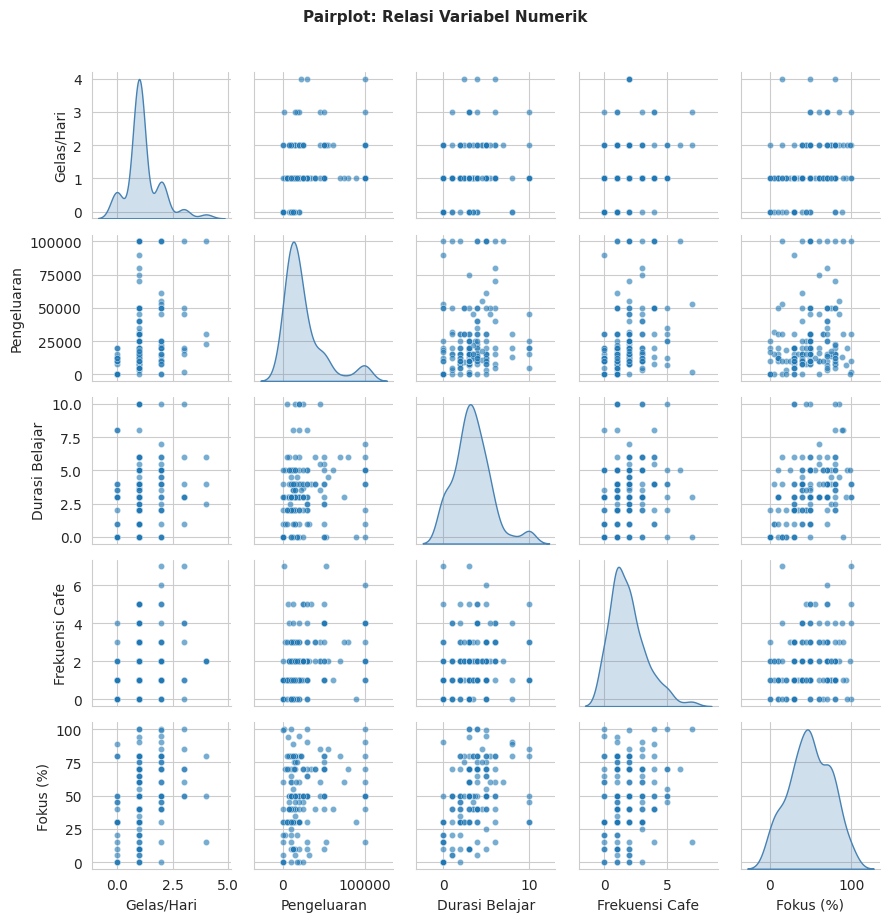

In [21]:
print("Pairplot untuk melihat relasi antar variabel numerik")

important_cols = ['gelas_num', 'pengeluaran_num', 'durasi_num',
                  'frekuensi_cafe_num', 'fokus_num']
important_labels = ['Gelas/Hari', 'Pengeluaran', 'Durasi Belajar',
                    'Frekuensi Cafe', 'Fokus (%)']

pairplot_df = df[important_cols].copy()
pairplot_df.columns = important_labels

g = sns.pairplot(pairplot_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20},
                 diag_kws={'color': 'steelblue', 'linewidth': 1},
                 height=1.8, aspect=1)
g.fig.suptitle('Pairplot: Relasi Variabel Numerik',
               fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

VISUALISASI VARIABEL KATEGORIKAL


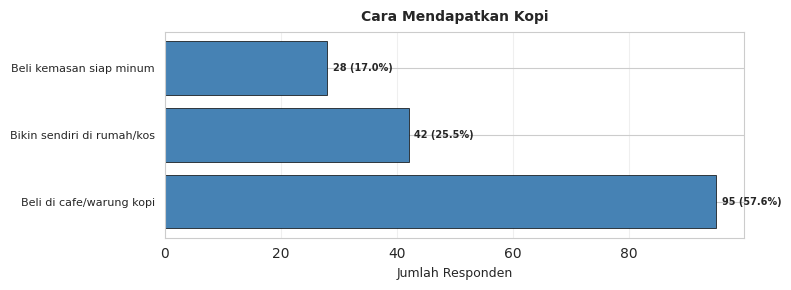

Cara Mendapatkan Kopi:
  Total kategori: 3
  Kategori terbanyak: Beli di cafe/warung kopi (95 - 57.6%)


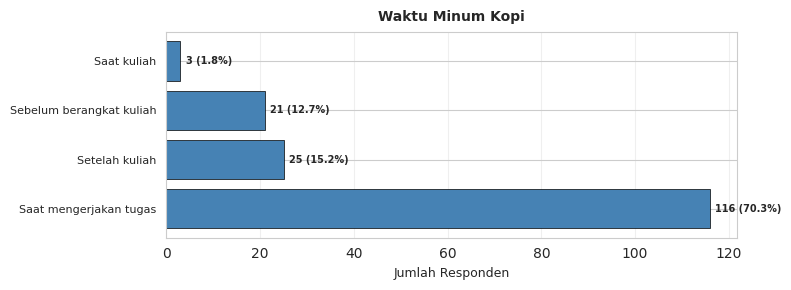

Waktu Minum Kopi:
  Total kategori: 4
  Kategori terbanyak: Saat mengerjakan tugas (116 - 70.3%)


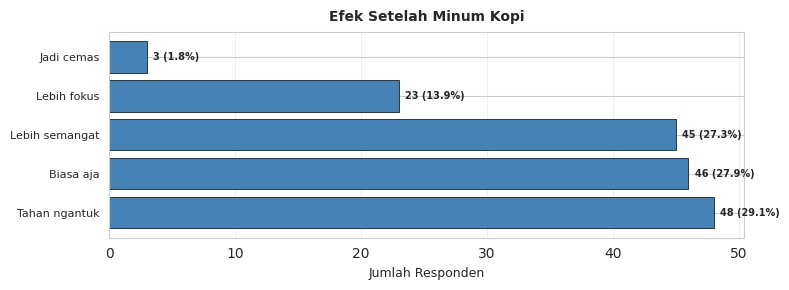

Efek Setelah Minum Kopi:
  Total kategori: 5
  Kategori terbanyak: Tahan ngantuk (48 - 29.1%)


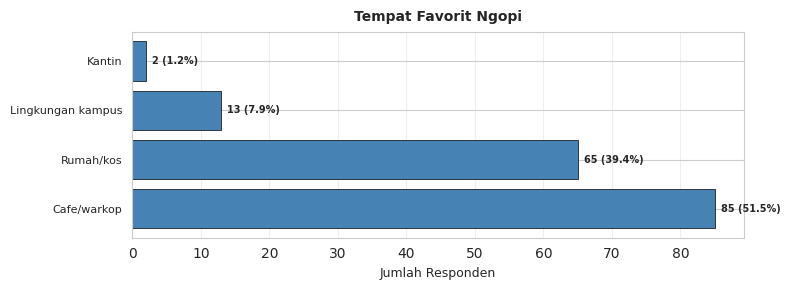

Tempat Favorit Ngopi:
  Total kategori: 4
  Kategori terbanyak: Cafe/warkop (85 - 51.5%)


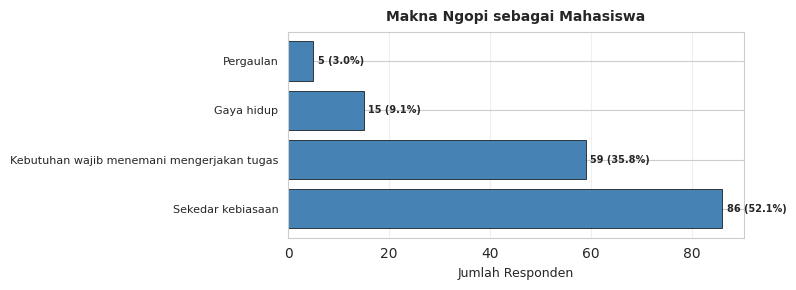

Makna Ngopi sebagai Mahasiswa:
  Total kategori: 4
  Kategori terbanyak: Sekedar kebiasaan (86 - 52.1%)


In [22]:
print("VISUALISASI VARIABEL KATEGORIKAL")

categorical_cols = {
    'cara_dapat_kopi': 'Cara Mendapatkan Kopi',
    'waktu_ngopi': 'Waktu Minum Kopi',
    'efek_kopi': 'Efek Setelah Minum Kopi',
    'tempat_favorit': 'Tempat Favorit Ngopi',
    'makna_ngopi': 'Makna Ngopi sebagai Mahasiswa'
}

for col, label in categorical_cols.items():
    # Hitung frekuensi dan persentase
    value_counts = df[col].value_counts()
    percentages = (value_counts / len(df) * 100).round(1)

    # Buat plot dengan ukuran lebih kecil
    fig, ax = plt.subplots(figsize=(8, max(3, len(value_counts) * 0.25)))

    bars = ax.barh(range(len(value_counts)), value_counts.values,
                   color='steelblue', edgecolor='black', linewidth=0.5)

    ax.set_yticks(range(len(value_counts)))
    ax.set_yticklabels(value_counts.index, fontsize=8)
    ax.set_xlabel('Jumlah Responden', fontsize=9)
    ax.set_title(f'{label}', fontsize=10, fontweight='bold', pad=8)
    ax.grid(True, alpha=0.3, axis='x')

    # Tambahkan label nilai dan persentase
    for i, (count, pct) in enumerate(zip(value_counts.values, percentages.values)):
        ax.text(count + max(value_counts)*0.01, i,
                f'{count} ({pct}%)',
                va='center', fontsize=7, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print statistik
    print(f"{label}:")
    print(f"  Total kategori: {len(value_counts)}")
    print(f"  Kategori terbanyak: {value_counts.index[0]} ({value_counts.values[0]} - {percentages.values[0]}%)")

Pie Chart untuk melihat persentase variabel kategorikal


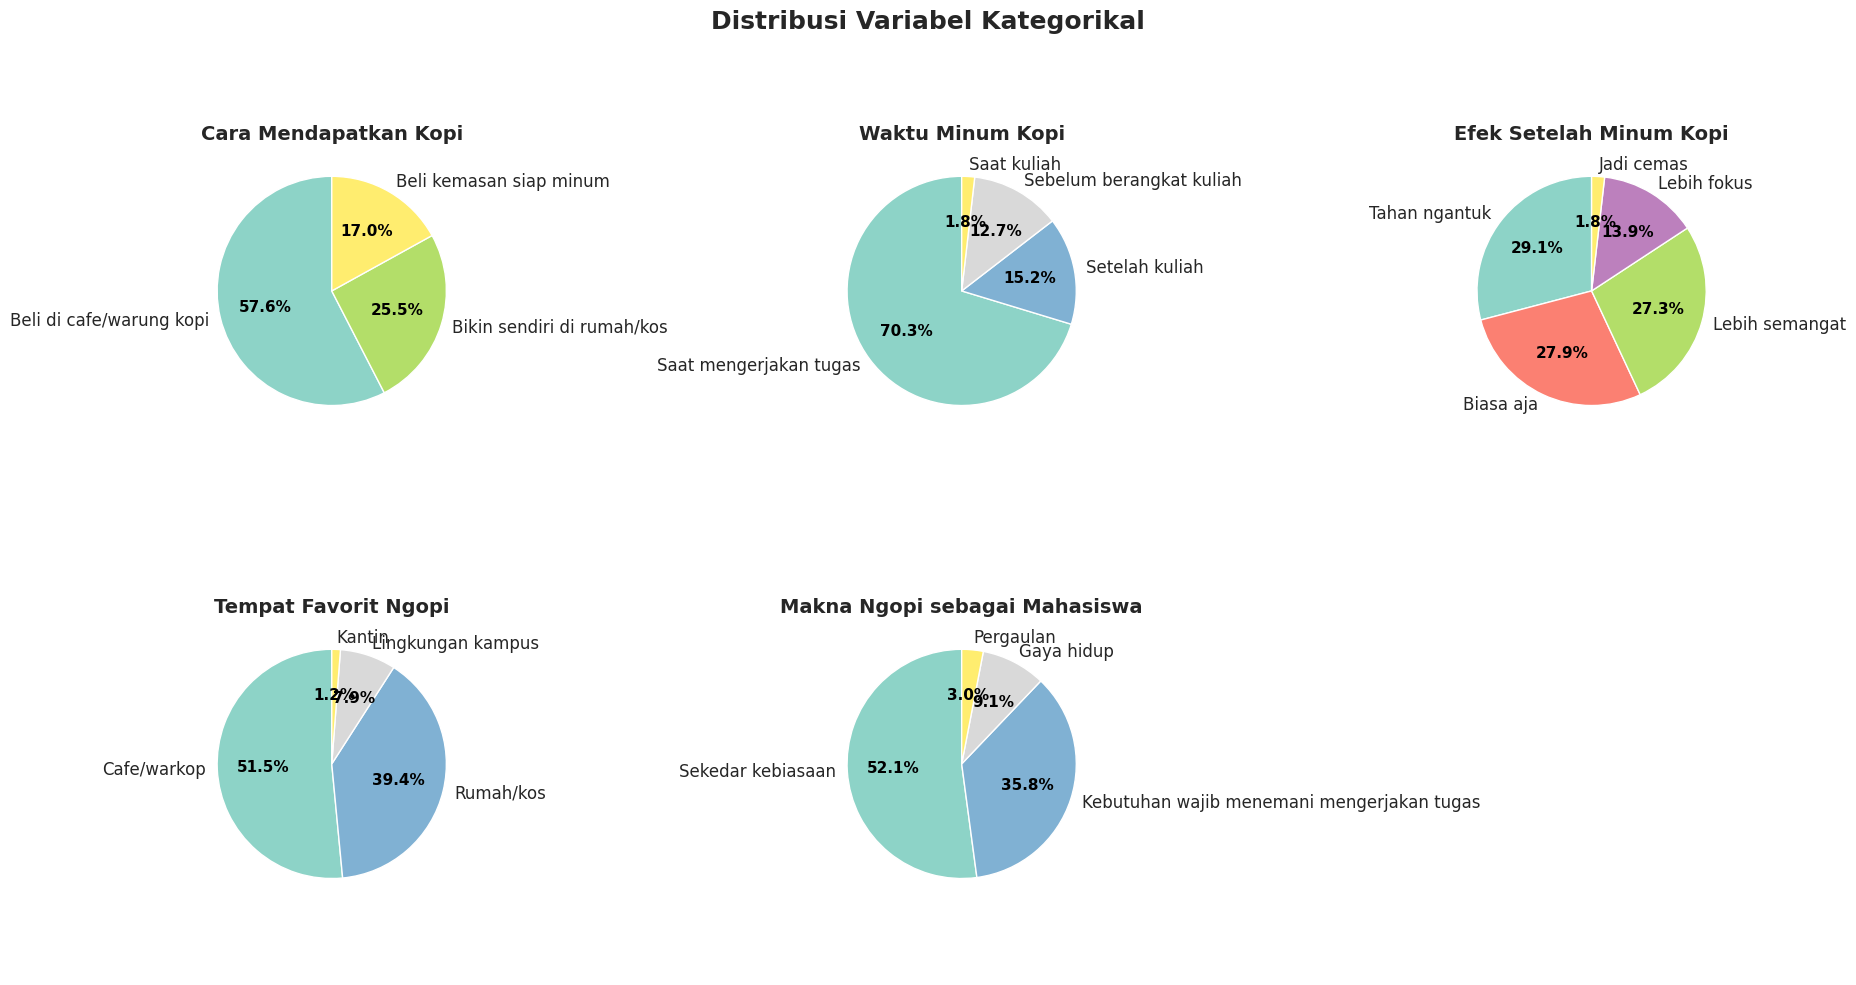

In [23]:
print("Pie Chart untuk melihat persentase variabel kategorikal")

pie_cols = ['cara_dapat_kopi', 'waktu_ngopi', 'efek_kopi',
            'tempat_favorit', 'makna_ngopi']
pie_labels_dict = {
    'cara_dapat_kopi': 'Cara Mendapatkan Kopi',
    'waktu_ngopi': 'Waktu Minum Kopi',
    'efek_kopi': 'Efek Setelah Minum Kopi',
    'tempat_favorit': 'Tempat Favorit Ngopi',
    'makna_ngopi': 'Makna Ngopi sebagai Mahasiswa'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(pie_cols):
    ax = axes[idx]

    value_counts = df[col].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(value_counts)))

    wedges, texts, autotexts = ax.pie(value_counts.values,
                                        labels=value_counts.index,
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        colors=colors,
                                        textprops={'fontsize': 11},
                                        radius=1.1)

    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)

    for text in texts:
        text.set_fontsize(12)

    ax.set_title(pie_labels_dict[col], fontsize=14, fontweight='bold', pad=15)

axes[-1].axis('off')

plt.suptitle('Distribusi Variabel Kategorikal',
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## **Analisis Cross-Tabulation**

Analisis: Konsumsi Kopi vs Pengeluaran
Apakah yang minum lebih banyak juga mengeluarkan uang lebih banyak?


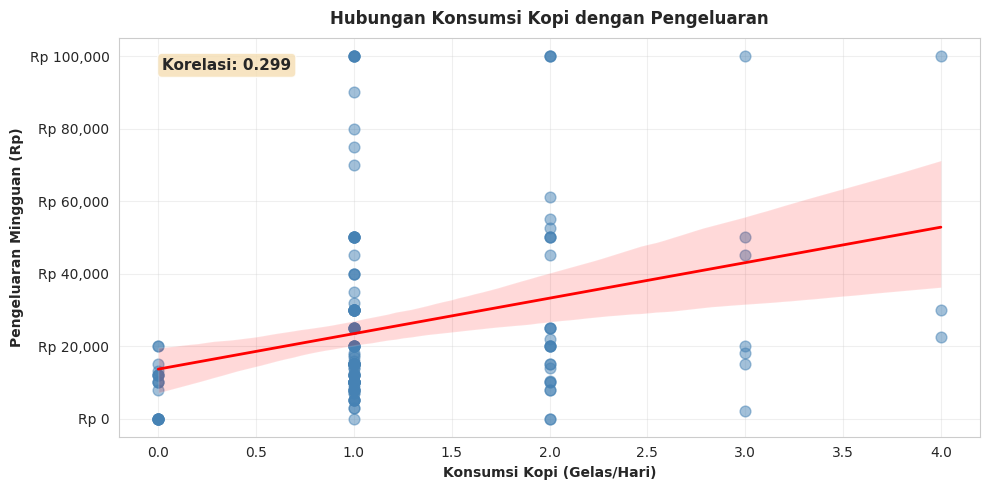

In [24]:
print("Analisis: Konsumsi Kopi vs Pengeluaran")
print("Apakah yang minum lebih banyak juga mengeluarkan uang lebih banyak?")

plt.figure(figsize=(10, 5))

# Scatter plot dengan regression line
sns.regplot(data=df, x='gelas_num', y='pengeluaran_num',
            scatter_kws={'alpha': 0.5, 's': 60, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})

plt.xlabel('Konsumsi Kopi (Gelas/Hari)', fontsize=10, fontweight='bold')
plt.ylabel('Pengeluaran Mingguan (Rp)', fontsize=10, fontweight='bold')
plt.title('Hubungan Konsumsi Kopi dengan Pengeluaran',
          fontsize=12, fontweight='bold', pad=10)
plt.grid(True, alpha=0.3)

# Format y-axis ke rupiah
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp {x:,.0f}'))

# Hitung korelasi
corr = df[['gelas_num', 'pengeluaran_num']].corr().iloc[0, 1]
plt.text(0.05, 0.95, f'Korelasi: {corr:.3f}',
         transform=ax.transAxes, fontsize=11, fontweight='bold',
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

Analisis: Efek Kopi vs Durasi Belajar
Apakah yang merasakan efek positif bisa belajar lebih lama?


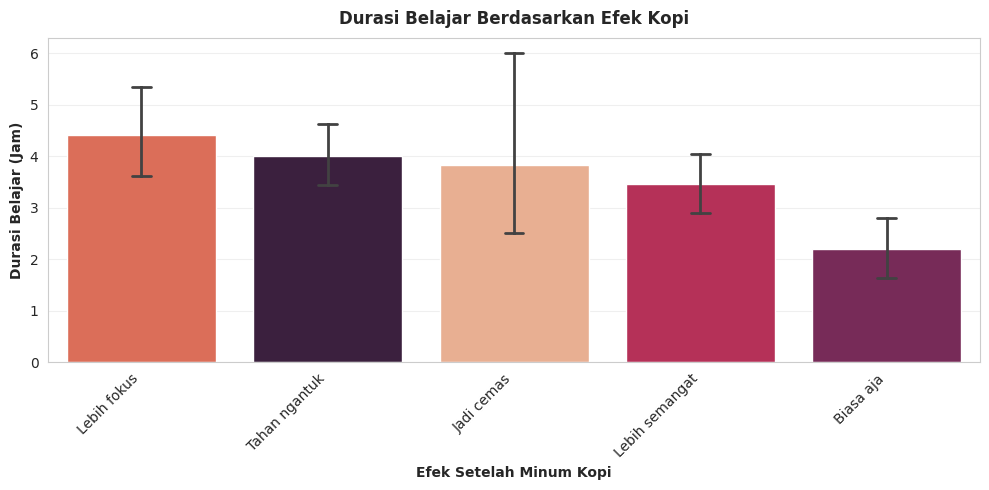

Rata-rata Durasi Belajar berdasarkan Efek Kopi:
                mean  median   std  count
efek_kopi                                
Lebih fokus     4.42     3.5  2.22     23
Tahan ngantuk   4.00     4.0  2.09     48
Jadi cemas      3.83     3.0  1.89      3
Lebih semangat  3.47     3.5  1.98     45
Biasa aja       2.21     2.0  2.02     46


In [25]:
print("Analisis: Efek Kopi vs Durasi Belajar")
print("Apakah yang merasakan efek positif bisa belajar lebih lama?")

plt.figure(figsize=(10, 5))

efek_order2 = df.groupby('efek_kopi')['durasi_num'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='efek_kopi', y='durasi_num',
            order=efek_order2, hue='efek_kopi', legend=False, palette='rocket',
            capsize=0.1, err_kws={'linewidth': 2})

plt.xticks(rotation=45, ha='right')
plt.xlabel('Efek Setelah Minum Kopi', fontsize=10, fontweight='bold')
plt.ylabel('Durasi Belajar (Jam)', fontsize=10, fontweight='bold')
plt.title('Durasi Belajar Berdasarkan Efek Kopi',
          fontsize=12, fontweight='bold', pad=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Statistik
print("Rata-rata Durasi Belajar berdasarkan Efek Kopi:")
mean_by_efek2 = df.groupby('efek_kopi')['durasi_num'].agg(['mean', 'median', 'std', 'count'])
print(mean_by_efek2.sort_values('mean', ascending=False).round(2))

Analisis: Cara Mendapatkan Kopi vs Pengeluaran
Mana yang lebih hemat: beli atau bikin sendiri?


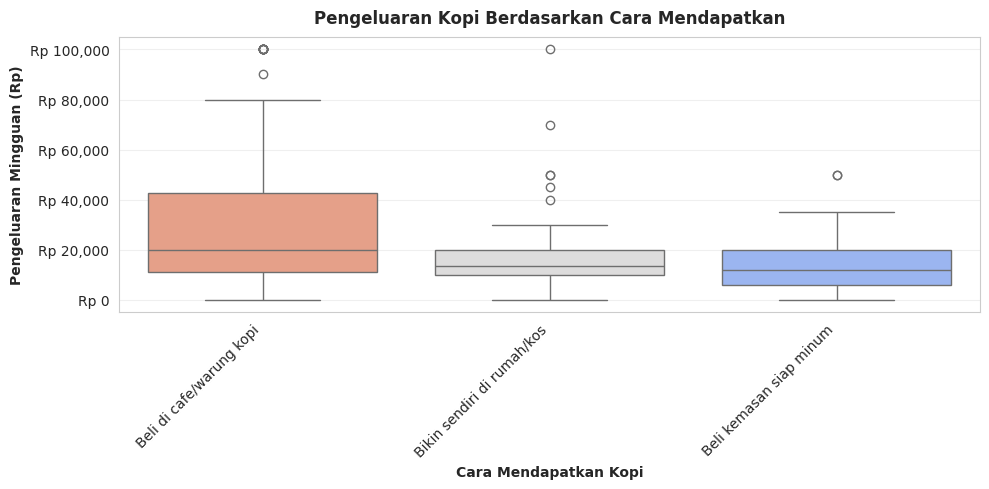

Rata-rata Pengeluaran berdasarkan Cara Dapat Kopi:
                               mean   median      std  count
cara_dapat_kopi                                             
Beli di cafe/warung kopi    30900.0  20000.0  28460.0     95
Bikin sendiri di rumah/kos  19476.0  13500.0  19413.0     42
Beli kemasan siap minum     14857.0  12000.0  13493.0     28


In [26]:
print("Analisis: Cara Mendapatkan Kopi vs Pengeluaran")
print("Mana yang lebih hemat: beli atau bikin sendiri?")

plt.figure(figsize=(10, 5))

cara_order = df.groupby('cara_dapat_kopi')['pengeluaran_num'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='cara_dapat_kopi', y='pengeluaran_num',
            order=cara_order, hue='cara_dapat_kopi', legend=False, palette='coolwarm')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Cara Mendapatkan Kopi', fontsize=10, fontweight='bold')
plt.ylabel('Pengeluaran Mingguan (Rp)', fontsize=10, fontweight='bold')
plt.title('Pengeluaran Kopi Berdasarkan Cara Mendapatkan',
          fontsize=12, fontweight='bold', pad=10)
plt.grid(True, alpha=0.3, axis='y')

# Format y-axis ke rupiah
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp {x:,.0f}'))

plt.tight_layout()
plt.show()

# Statistik
print("Rata-rata Pengeluaran berdasarkan Cara Dapat Kopi:")
mean_by_cara = df.groupby('cara_dapat_kopi')['pengeluaran_num'].agg(['mean', 'median', 'std', 'count'])
print(mean_by_cara.sort_values('mean', ascending=False).round(0))

Analisis: Efek Kopi vs Tingkat Fokus
Apakah efek yang dirasakan sesuai dengan tingkat fokus?


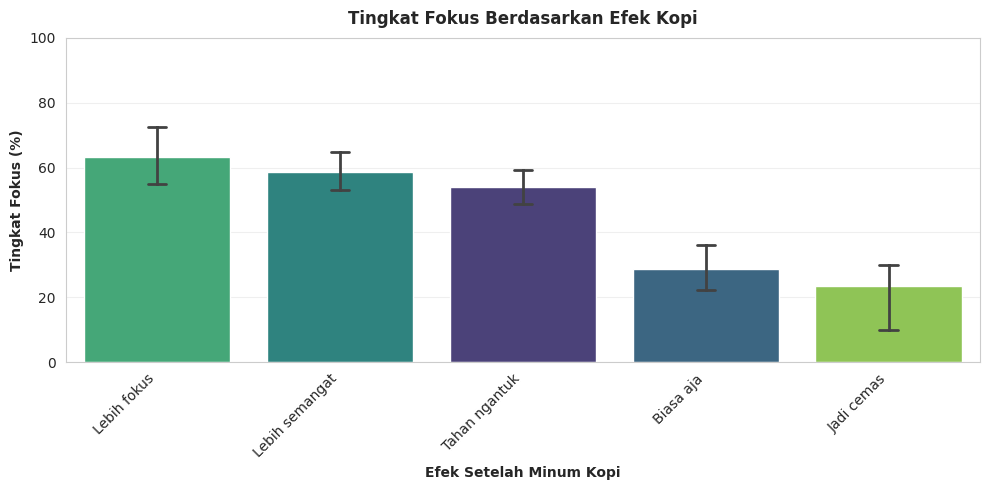

Rata-rata Tingkat Fokus berdasarkan Efek Kopi:
                 mean  median    std  count
efek_kopi                                  
Lebih fokus     63.39    55.0  21.54     23
Lebih semangat  58.53    50.0  21.61     45
Tahan ngantuk   53.96    50.0  19.38     48
Biasa aja       28.80    30.0  24.52     46
Jadi cemas      23.33    30.0  11.55      3


In [27]:
print("Analisis: Efek Kopi vs Tingkat Fokus")
print("Apakah efek yang dirasakan sesuai dengan tingkat fokus?")

plt.figure(figsize=(10, 5))

efek_order = df.groupby('efek_kopi')['fokus_num'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='efek_kopi', y='fokus_num',
            order=efek_order, hue='efek_kopi', legend=False, palette='viridis',
            capsize=0.1, err_kws={'linewidth': 2})

plt.xticks(rotation=45, ha='right')
plt.xlabel('Efek Setelah Minum Kopi', fontsize=10, fontweight='bold')
plt.ylabel('Tingkat Fokus (%)', fontsize=10, fontweight='bold')
plt.title('Tingkat Fokus Berdasarkan Efek Kopi',
          fontsize=12, fontweight='bold', pad=10)
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Statistik
print("Rata-rata Tingkat Fokus berdasarkan Efek Kopi:")
mean_by_efek = df.groupby('efek_kopi')['fokus_num'].agg(['mean', 'median', 'std', 'count'])
print(mean_by_efek.sort_values('mean', ascending=False).round(2))

Analisis: Tempat Favorit vs Cara Mendapatkan Kopi
Apakah ada pola antara tempat favorit dan cara dapat kopi?


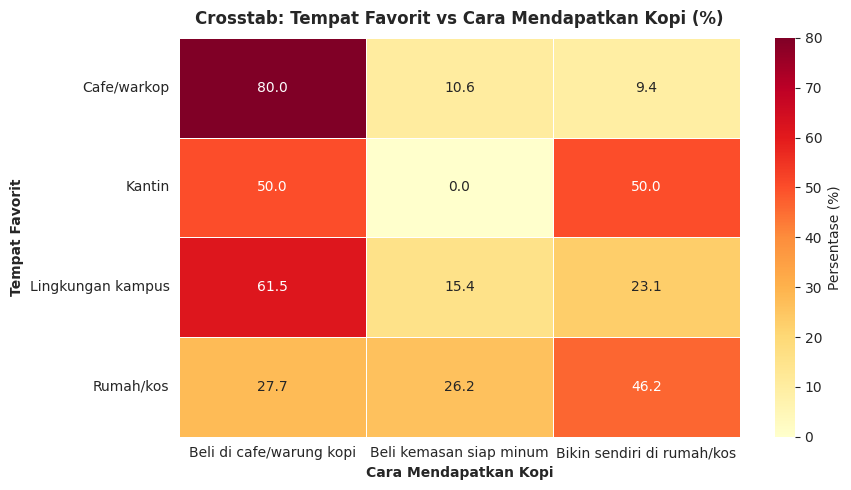

Crosstab (Count):
cara_dapat_kopi    Beli di cafe/warung kopi  Beli kemasan siap minum  \
tempat_favorit                                                         
Cafe/warkop                              68                        9   
Kantin                                    1                        0   
Lingkungan kampus                         8                        2   
Rumah/kos                                18                       17   

cara_dapat_kopi    Bikin sendiri di rumah/kos  
tempat_favorit                                 
Cafe/warkop                                 8  
Kantin                                      1  
Lingkungan kampus                           3  
Rumah/kos                                  30  


In [28]:
print("Analisis: Tempat Favorit vs Cara Mendapatkan Kopi")
print("Apakah ada pola antara tempat favorit dan cara dapat kopi?")

crosstab = pd.crosstab(df['tempat_favorit'], df['cara_dapat_kopi'],
                       normalize='index') * 100

plt.figure(figsize=(9, 5))
sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Persentase (%)'})

plt.xlabel('Cara Mendapatkan Kopi', fontsize=10, fontweight='bold')
plt.ylabel('Tempat Favorit', fontsize=10, fontweight='bold')
plt.title('Crosstab: Tempat Favorit vs Cara Mendapatkan Kopi (%)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

print("Crosstab (Count):")
crosstab_count = pd.crosstab(df['tempat_favorit'], df['cara_dapat_kopi'])
print(crosstab_count)

## **Analisis Data Eksploratif**

In [29]:
print("ANALISIS 1: POLA KONSUMSI DAN KEBIASAAN NGOPI MAHASISWA")
print(" ")

print("Frekuensi Konsumsi (Gelas per Hari)")
print(f"Modus: {df['gelas_num'].mode()[0]} gelas")
print("Distribusi:")
for val, count in df['gelas_num'].value_counts().sort_index().items():
    pct = (count/len(df)*100)
    print(f"  {val} gelas: {count} mahasiswa ({pct:.1f}%)")

ANALISIS 1: POLA KONSUMSI DAN KEBIASAAN NGOPI MAHASISWA
 
Frekuensi Konsumsi (Gelas per Hari)
Modus: 1.0 gelas
Distribusi:
  0.0 gelas: 20 mahasiswa (12.1%)
  1.0 gelas: 107 mahasiswa (64.8%)
  2.0 gelas: 28 mahasiswa (17.0%)
  3.0 gelas: 7 mahasiswa (4.2%)
  4.0 gelas: 3 mahasiswa (1.8%)


In [30]:
print("Pengeluaran per Minggu")
print(f"Median: Rp {df['pengeluaran_num'].median():,.0f}")

# Kategorisasi
def kategori_pengeluaran(val):
    if val == 0: return 'Tidak mengeluarkan'
    elif val < 15000: return '< Rp 15rb'
    elif val < 30000: return 'Rp 15-30rb'
    elif val < 50000: return 'Rp 30-50rb'
    elif val < 100000: return 'Rp 50-100rb'
    else: return '≥ Rp 100rb'

df['kat_pengeluaran'] = df['pengeluaran_num'].apply(kategori_pengeluaran)
print("Distribusi Pengeluaran:")
for kat, count in df['kat_pengeluaran'].value_counts().items():
    pct = (count/len(df)*100)
    print(f"  {kat}: {count} mahasiswa ({pct:.1f}%)")

Pengeluaran per Minggu
Median: Rp 15,000
Distribusi Pengeluaran:
  < Rp 15rb: 58 mahasiswa (35.2%)
  Rp 15-30rb: 48 mahasiswa (29.1%)
  Rp 30-50rb: 20 mahasiswa (12.1%)
  Rp 50-100rb: 18 mahasiswa (10.9%)
  Tidak mengeluarkan: 11 mahasiswa (6.7%)
  ≥ Rp 100rb: 10 mahasiswa (6.1%)


In [31]:
print("Cara Mendapatkan Kopi")
for cara, count in df['cara_dapat_kopi'].value_counts().items():
    pct = (count/len(df)*100)
    print(f"  {cara}: {count} mahasiswa ({pct:.1f}%)")

print("Tempat Favorit")
for tempat, count in df['tempat_favorit'].value_counts().items():
    pct = (count/len(df)*100)
    print(f"  {tempat}: {count} mahasiswa ({pct:.1f}%)")

print("Waktu Ngopi")
for waktu, count in df['waktu_ngopi'].value_counts().items():
    pct = (count/len(df)*100)
    print(f"  {waktu}: {count} mahasiswa ({pct:.1f}%)")

print("Frekuensi di Cafe")
print(f"Median: {df['frekuensi_cafe_num'].median()} kali/minggu")

Cara Mendapatkan Kopi
  Beli di cafe/warung kopi: 95 mahasiswa (57.6%)
  Bikin sendiri di rumah/kos: 42 mahasiswa (25.5%)
  Beli kemasan siap minum: 28 mahasiswa (17.0%)
Tempat Favorit
  Cafe/warkop: 85 mahasiswa (51.5%)
  Rumah/kos: 65 mahasiswa (39.4%)
  Lingkungan kampus: 13 mahasiswa (7.9%)
  Kantin: 2 mahasiswa (1.2%)
Waktu Ngopi
  Saat mengerjakan tugas: 116 mahasiswa (70.3%)
  Setelah kuliah: 25 mahasiswa (15.2%)
  Sebelum berangkat kuliah: 21 mahasiswa (12.7%)
  Saat kuliah: 3 mahasiswa (1.8%)
Frekuensi di Cafe
Median: 2.0 kali/minggu


Hasil analisis menunjukkan bahwa sebagian besar mahasiswa (64,8%) minum satu gelas kopi per hari dengan pengeluaran rata-rata sekitar Rp15.000 per minggu. Sebagian besar (70,3%) minum kopi saat mengerjakan tugas dan memdapatkannya dengan cara beli di cafe atau warung (57%), sehingga dapat disimpulkan bahwa kopi lebih sering digunakan untuk mendukung kegiatan belajar daripada sekadar untuk bersantai. Tempat ngopi yang paling sering dipilih adalah cafe atau warkop (51,5%), diikuti oleh rumah atau kos (39,4%), kemudian disusul area kampus (9,1%). Frekuensi ke cafe juga tidak terlalu sering, yaitu sekitar dua kali dalam seminggu. Secara umum, mahasiswa memiliki kebiasaan ngopi yang wajar dan sesuai kebutuhan, dengan pengeluaran yang masih terjaga serta tujuan utama untuk membantu fokus saat belajar.

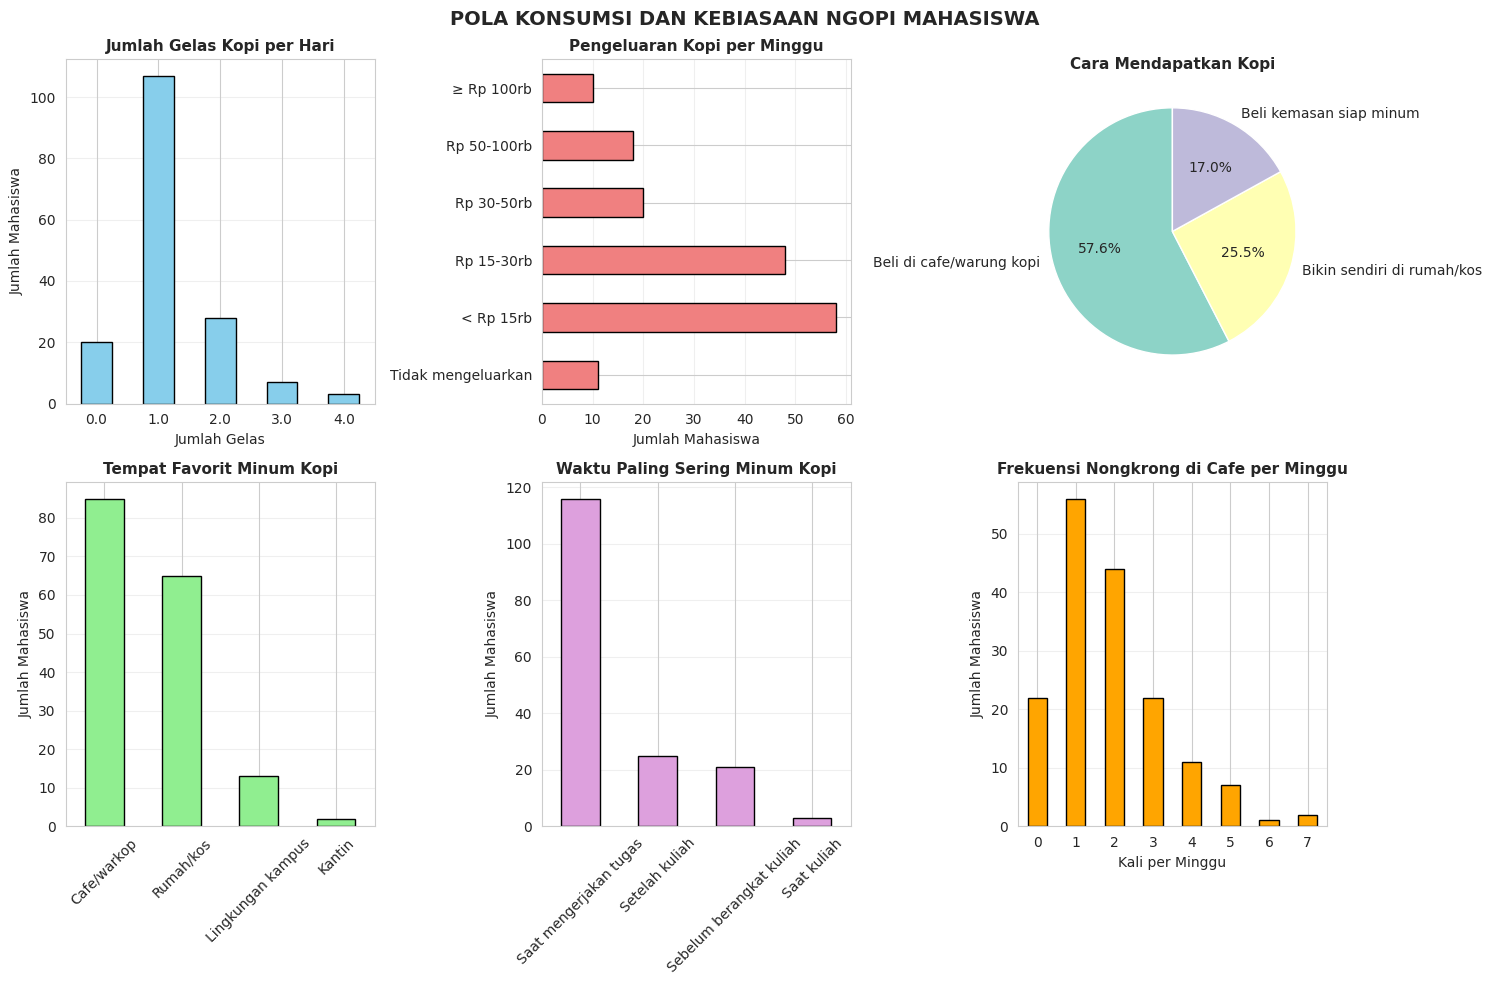

In [32]:
fig1, axes = plt.subplots(2, 3, figsize=(15, 10))
fig1.suptitle('POLA KONSUMSI DAN KEBIASAAN NGOPI MAHASISWA',
              fontsize=14, fontweight='bold', y=0.98)

# Gelas per hari
ax1 = axes[0, 0]
df['gelas_num'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Jumlah Gelas Kopi per Hari', fontweight='bold', fontsize=11)
ax1.set_xlabel('Jumlah Gelas')
ax1.set_ylabel('Jumlah Mahasiswa')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=0)

# Pengeluaran
ax2 = axes[0, 1]
kat_order = ['Tidak mengeluarkan', '< Rp 15rb', 'Rp 15-30rb',
             'Rp 30-50rb', 'Rp 50-100rb', '≥ Rp 100rb']
df['kat_pengeluaran'].value_counts().reindex(kat_order).plot(
    kind='barh', ax=ax2, color='lightcoral', edgecolor='black')
ax2.set_title('Pengeluaran Kopi per Minggu', fontweight='bold', fontsize=11)
ax2.set_xlabel('Jumlah Mahasiswa')
ax2.set_ylabel('')
ax2.grid(axis='x', alpha=0.3)

# Cara dapat kopi
ax3 = axes[0, 2]
cara_counts = df['cara_dapat_kopi'].value_counts()
colors = plt.cm.Set3(range(len(cara_counts)))
ax3.pie(cara_counts, labels=cara_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax3.set_title('Cara Mendapatkan Kopi', fontweight='bold', fontsize=11)

# Tempat favorit
ax4 = axes[1, 0]
df['tempat_favorit'].value_counts().plot(kind='bar', ax=ax4,
                                         color='lightgreen', edgecolor='black')
ax4.set_title('Tempat Favorit Minum Kopi', fontweight='bold', fontsize=11)
ax4.set_xlabel('')
ax4.set_ylabel('Jumlah Mahasiswa')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

# Waktu ngopi
ax5 = axes[1, 1]
df['waktu_ngopi'].value_counts().plot(kind='bar', ax=ax5,
                                      color='plum', edgecolor='black')
ax5.set_title('Waktu Paling Sering Minum Kopi', fontweight='bold', fontsize=11)
ax5.set_xlabel('')
ax5.set_ylabel('Jumlah Mahasiswa')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(axis='y', alpha=0.3)

# Frekuensi cafe
ax6 = axes[1, 2]
df['frekuensi_cafe_num'].value_counts().sort_index().plot(
    kind='bar', ax=ax6, color='orange', edgecolor='black')
ax6.set_title('Frekuensi Nongkrong di Cafe per Minggu', fontweight='bold', fontsize=11)
ax6.set_xlabel('Kali per Minggu')
ax6.set_ylabel('Jumlah Mahasiswa')
ax6.tick_params(axis='x', rotation=0)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Visualisasi terdiri dari enam grafik yang menampilkan berbagai aspek kebiasaan ngopi mahasiswa.

Diagram batang vertikal menunjukkan bahwa sebagian besar mahasiswa hanya minum satu gelas kopi per hari, dengan jumlah responden paling banyak dibanding kategori lainnya.

Diagram batang horizontal untuk pengeluaran mingguan memperlihatkan bahwa sebagian besar berada pada kategori di bawah Rp30.000, menunjukkan kebiasaan ngopi yang masih hemat.

Diagram lingkaran mengenai cara mendapatkan kopi memperlihatkan bahwa 57% mahasiswa membeli kopi di cafe atau warung, sedangkan sisanya membuat sendiri di rumah atau kos.

Grafik tempat favorit minum kopi menunjukkan bahwa cafe atau warkop menjadi pilihan utama, disusul rumah atau kos, sedangkan area kampus paling sedikit dipilih.

Grafik waktu minum kopi memperlihatkan perbedaan tinggi batang yang mencolok, di mana kategori “saat mengerjakan tugas” hampir empat kali lebih tinggi dari kategori lainnya, menandakan bahwa kopi paling sering diminum untuk membantu belajar.

Sementara itu, grafik frekuensi ke cafe membentuk pola seimbang dengan puncak pada 1–2 kali per minggu, yang menunjukkan bahwa sebagian besar mahasiswa tidak terlalu sering pergi ke cafe.

In [33]:
print("ANALISIS 2: PERAN KOPI TERHADAP FOKUS DAN DURASI BELAJAR")
print(" ")

print("Persepsi Peningkatan Fokus (%)")
def kategori_fokus(val):
    if val == 0: return 'Tidak membantu'
    elif val <= 30: return 'Rendah (1-30%)'
    elif val <= 50: return 'Sedang (31-50%)'
    elif val <= 70: return 'Tinggi (51-70%)'
    else: return 'Sangat Tinggi (>70%)'

df['kat_fokus'] = df['fokus_num'].apply(kategori_fokus)
print("Distribusi Persepsi Fokus:")
for kat in ['Tidak membantu', 'Rendah (1-30%)', 'Sedang (31-50%)',
            'Tinggi (51-70%)', 'Sangat Tinggi (>70%)']:
    count = (df['kat_fokus'] == kat).sum()
    pct = (count/len(df)*100)
    print(f"  {kat}: {count} mahasiswa ({pct:.1f}%)")

ANALISIS 2: PERAN KOPI TERHADAP FOKUS DAN DURASI BELAJAR
 
Persepsi Peningkatan Fokus (%)
Distribusi Persepsi Fokus:
  Tidak membantu: 7 mahasiswa (4.2%)
  Rendah (1-30%): 43 mahasiswa (26.1%)
  Sedang (31-50%): 53 mahasiswa (32.1%)
  Tinggi (51-70%): 30 mahasiswa (18.2%)
  Sangat Tinggi (>70%): 32 mahasiswa (19.4%)


In [34]:
print("Durasi Tahan Belajar (Jam)")

def kategori_durasi(val):
    if val == 0: return 'Tidak berpengaruh'
    elif val <= 2: return '1-2 jam'
    elif val <= 4: return '3-4 jam'
    elif val <= 6: return '5-6 jam'
    else: return '> 6 jam'

df['kat_durasi'] = df['durasi_num'].apply(kategori_durasi)
print("Distribusi Durasi:")
for kat in ['Tidak berpengaruh', '1-2 jam', '3-4 jam', '5-6 jam', '> 6 jam']:
    count = (df['kat_durasi'] == kat).sum()
    pct = (count/len(df)*100)
    print(f"  {kat}: {count} mahasiswa ({pct:.1f}%)")

Durasi Tahan Belajar (Jam)
Distribusi Durasi:
  Tidak berpengaruh: 17 mahasiswa (10.3%)
  1-2 jam: 33 mahasiswa (20.0%)
  3-4 jam: 71 mahasiswa (43.0%)
  5-6 jam: 34 mahasiswa (20.6%)
  > 6 jam: 10 mahasiswa (6.1%)


In [35]:
print("Efek Utama Setelah Minum Kopi")
for efek, count in df['efek_kopi'].value_counts().items():
    pct = (count/len(df)*100)
    print(f"  {efek}: {count} mahasiswa ({pct:.1f}%)")

print("Korelasi Antar Variabel")
corr_cols = ['gelas_num', 'durasi_num', 'fokus_num', 'frekuensi_cafe_num']
correlation = df[corr_cols].corr()
print(correlation.round(3))

Efek Utama Setelah Minum Kopi
  Tahan ngantuk: 48 mahasiswa (29.1%)
  Biasa aja: 46 mahasiswa (27.9%)
  Lebih semangat: 45 mahasiswa (27.3%)
  Lebih fokus: 23 mahasiswa (13.9%)
  Jadi cemas: 3 mahasiswa (1.8%)
Korelasi Antar Variabel
                    gelas_num  durasi_num  fokus_num  frekuensi_cafe_num
gelas_num               1.000       0.197      0.290               0.232
durasi_num              0.197       1.000      0.416               0.151
fokus_num               0.290       0.416      1.000               0.178
frekuensi_cafe_num      0.232       0.151      0.178               1.000


Analisis efektivitas kopi menunjukkan bahwa sebagian besar mahasiswa merasakan peningkatan fokus pada tingkat sedang (sekitar 31–50%) dan mampu belajar selama 3–4 jam setelah minum kopi, sejalan dengan durasi efek kafein yang bertahan 3–5 jam di tubuh. Hasil survei memperlihatkan variasi efek yang cukup besar, di mana 29,1% merasa lebih tahan ngantuk, 27,9% tidak merasakan perubahan, 27,3% merasa lebih semangat, dan hanya 13,9% yang benar-benar merasa lebih fokus, yang menunjukkan bahwa pengaruh kopi terhadap fokus bersifat berbeda pada setiap individu.

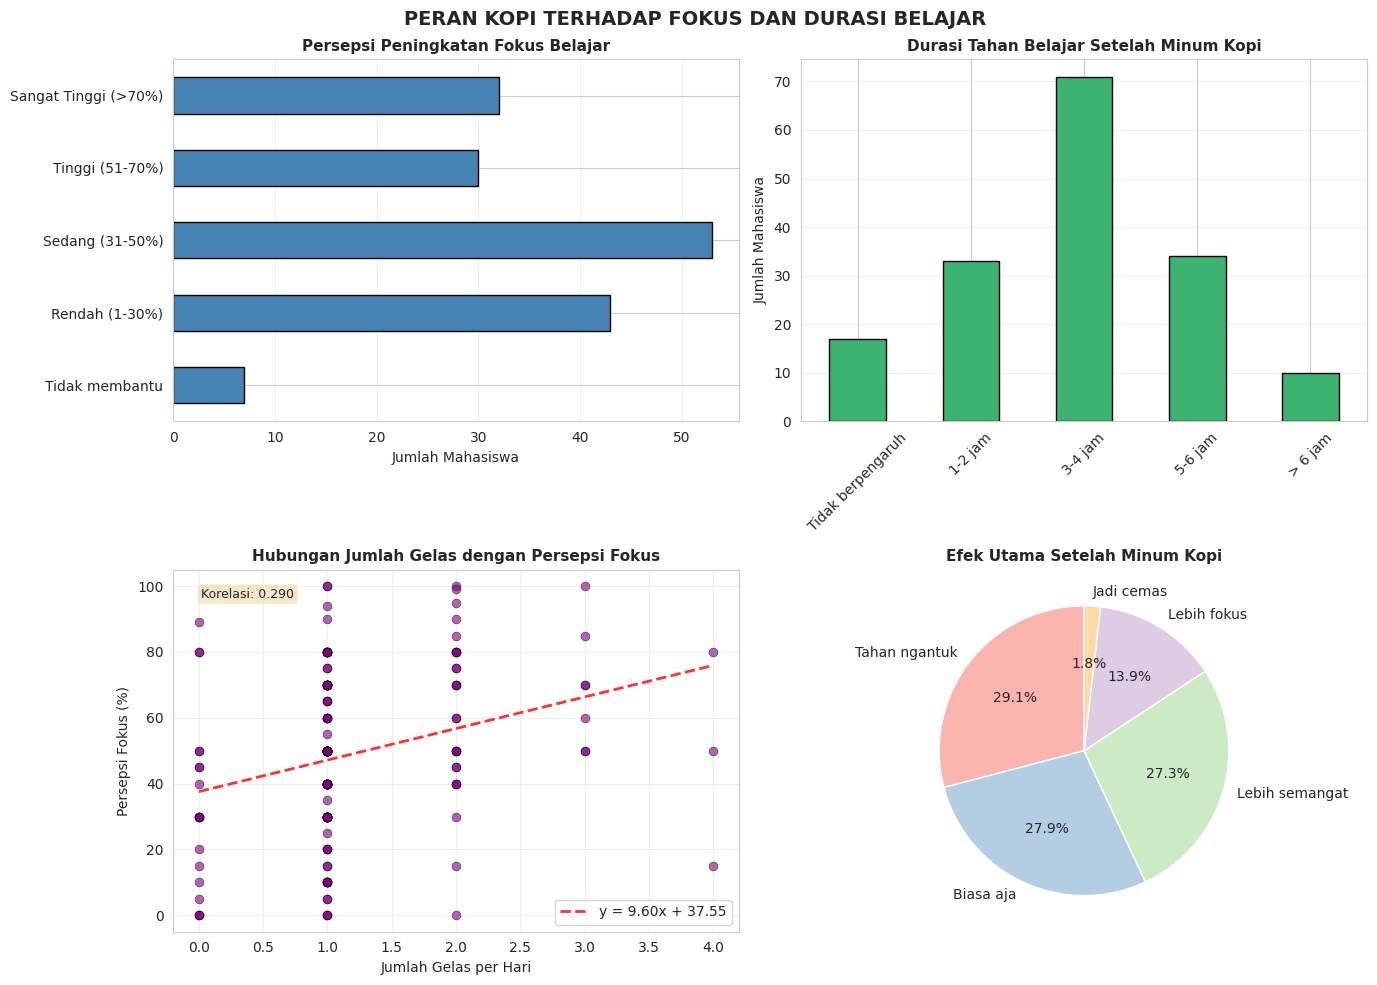

In [36]:
fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('PERAN KOPI TERHADAP FOKUS DAN DURASI BELAJAR',
              fontsize=14, fontweight='bold', y=0.98)

# Persepsi fokus
ax1 = axes[0, 0]
fokus_order = ['Tidak membantu', 'Rendah (1-30%)', 'Sedang (31-50%)',
               'Tinggi (51-70%)', 'Sangat Tinggi (>70%)']
df['kat_fokus'].value_counts().reindex(fokus_order).plot(
    kind='barh', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Persepsi Peningkatan Fokus Belajar', fontweight='bold', fontsize=11)
ax1.set_xlabel('Jumlah Mahasiswa')
ax1.set_ylabel('')
ax1.grid(axis='x', alpha=0.3)

# Durasi belajar
ax2 = axes[0, 1]
durasi_order = ['Tidak berpengaruh', '1-2 jam', '3-4 jam', '5-6 jam', '> 6 jam']
df['kat_durasi'].value_counts().reindex(durasi_order).plot(
    kind='bar', ax=ax2, color='mediumseagreen', edgecolor='black')
ax2.set_title('Durasi Tahan Belajar Setelah Minum Kopi', fontweight='bold', fontsize=11)
ax2.set_xlabel('')
ax2.set_ylabel('Jumlah Mahasiswa')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Scatter: Gelas vs Fokus
ax3 = axes[1, 0]
ax3.scatter(df['gelas_num'], df['fokus_num'], alpha=0.6,
            s=40, color='purple', edgecolors='black', linewidth=0.5)
ax3.set_title('Hubungan Jumlah Gelas dengan Persepsi Fokus',
              fontweight='bold', fontsize=11)
ax3.set_xlabel('Jumlah Gelas per Hari')
ax3.set_ylabel('Persepsi Fokus (%)')
ax3.grid(alpha=0.3)

# Trendline
z = np.polyfit(df['gelas_num'], df['fokus_num'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df['gelas_num'].min(), df['gelas_num'].max(), 100)
ax3.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2,
         label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
ax3.legend(loc='best')

# Korelasi
corr_val = df[['gelas_num', 'fokus_num']].corr().iloc[0, 1]
ax3.text(0.05, 0.95, f'Korelasi: {corr_val:.3f}',
         transform=ax3.transAxes, fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Efek utama
ax4 = axes[1, 1]
efek_counts = df['efek_kopi'].value_counts()
colors = plt.cm.Pastel1(range(len(efek_counts)))
ax4.pie(efek_counts, labels=efek_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax4.set_title('Efek Utama Setelah Minum Kopi', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

Visualisasi terdiri dari empat grafik yang menggambarkan pengaruh kopi terhadap fokus dan durasi belajar mahasiswa.

Diagram batang horizontal menunjukkan bahwa sebagian besar mahasiswa berada pada kategori “Sedang (31–50%)” dalam peningkatan fokus setelah minum kopi, sedangkan hanya sedikit yang merasa tidak terbantu, sehingga dapat disimpulkan bahwa kopi cukup membantu tetapi efeknya tidak terlalu tinggi bagi sebagian mahasiswa.

Grafik batang vertikal mengenai durasi belajar setelah minum kopi memperlihatkan bahwa mayoritas mahasiswa mampu bertahan belajar selama 3–4 jam, dengan jumlah responden yang jauh lebih banyak dibanding kategori lainnya.

Scatter plot menampilkan hubungan antara jumlah gelas kopi dan tingkat fokus dengan sebaran titik yang cukup lebar, serta garis tren merah yang landai, menunjukkan bahwa banyaknya kopi yang diminum memiliki pengaruh kecil terhadap peningkatan fokus (r = 0,290).

Sementara itu, diagram lingkaran memperlihatkan bahwa efek yang paling banyak dirasakan mahasiswa adalah tahan ngantuk (29,1%), lebih semangat (27,3%), dan biasa saja (27,9%), sedangkan hanya sebagian kecil yang merasa lebih fokus (13,9%) dan sedikit yang justru merasa cemas (1,8%), menegaskan bahwa respon terhadap kopi berbeda-beda pada setiap individu.

In [37]:
print("ANALISIS 3: MAKNA DAN FUNGSI NGOPI DALAM KEHIDUPAN MAHASISWA")
print(" ")

print("Makna Ngopi Bagi Mahasiswa")
for makna, count in df['makna_ngopi'].value_counts().items():
    pct = (count/len(df)*100)
    print(f"  {makna}: {count} mahasiswa ({pct:.1f}%)")

ANALISIS 3: MAKNA DAN FUNGSI NGOPI DALAM KEHIDUPAN MAHASISWA
 
Makna Ngopi Bagi Mahasiswa
  Sekedar kebiasaan: 86 mahasiswa (52.1%)
  Kebutuhan wajib menemani mengerjakan tugas: 59 mahasiswa (35.8%)
  Gaya hidup: 15 mahasiswa (9.1%)
  Pergaulan: 5 mahasiswa (3.0%)


In [38]:
print("Hubungan Makna dengan Frekuensi Konsumsi")
crosstab1 = pd.crosstab(df['makna_ngopi'], df['gelas_num'], margins=True)
print(crosstab1)

Hubungan Makna dengan Frekuensi Konsumsi
gelas_num                                   0.0  1.0  2.0  3.0  4.0  All
makna_ngopi                                                             
Gaya hidup                                    1    8    4    0    2   15
Kebutuhan wajib menemani mengerjakan tugas    6   39    8    5    1   59
Pergaulan                                     2    3    0    0    0    5
Sekedar kebiasaan                            11   57   16    2    0   86
All                                          20  107   28    7    3  165


In [39]:
print("Hubungan Makna dengan Pengeluaran")
crosstab2 = pd.crosstab(df['makna_ngopi'], df['kat_pengeluaran'], margins=True)
print(crosstab2)

Hubungan Makna dengan Pengeluaran
kat_pengeluaran                             < Rp 15rb  Rp 15-30rb  Rp 30-50rb  \
makna_ngopi                                                                     
Gaya hidup                                          5           5           2   
Kebutuhan wajib menemani mengerjakan tugas         20          17           9   
Pergaulan                                           1           2           0   
Sekedar kebiasaan                                  32          24           9   
All                                                58          48          20   

kat_pengeluaran                             Rp 50-100rb  Tidak mengeluarkan  \
makna_ngopi                                                                   
Gaya hidup                                            1                   1   
Kebutuhan wajib menemani mengerjakan tugas            8                   2   
Pergaulan                                             0                   2   
Sek

Analisis makna ngopi menunjukkan bahwa sebanyak 52,1% mahasiswa menganggap ngopi sebagai kebiasaan biasa, sedangkan 35,8% mahasiswa menilainya sebagai kebutuhan wajib saat mengerjakan tugas. Kedua kelompok memiliki pola konsumsi serupa, yaitu satu gelas per hari, sehingga perbedaan terletak pada cara pandang, bukan perilaku. Kelompok mahasiswa yang menganggap kopi sebagai “kebutuhan” cenderung mengeluarkan uang lebih banyak dibanding kelompok mahasiswa yang menganggap kopi sebagai “kebiasaan”, sementara kelompok mahasiswa yang menganggap kopi sebagai “gaya hidup” (9,1%) memiliki pola pengeluaran yang lebih beragam karena alasan selera dan pilihan tempat. Hanya 3% yang menganggap ngopi sebagai ajang sosial, menandakan bahwa kopi lebih berfungsi untuk mendukung aktivitas belajar daripada sekadar pergaulan.

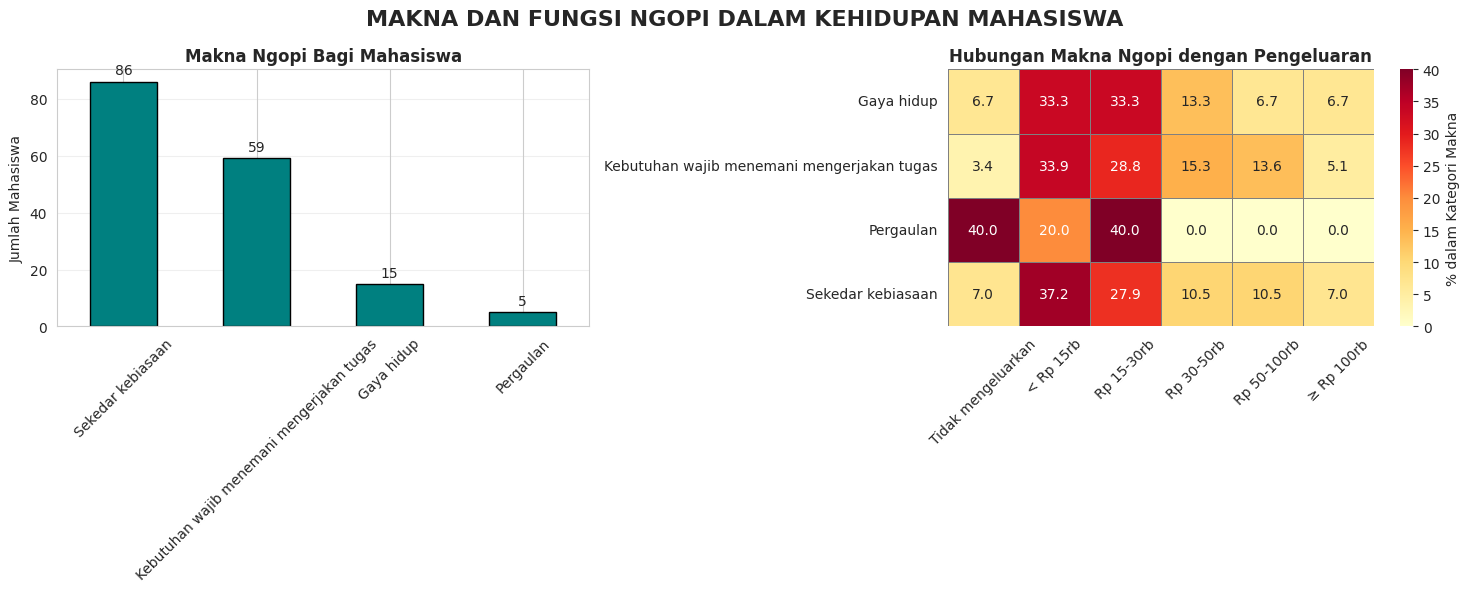

In [40]:
fig3, axes = plt.subplots(1, 2, figsize=(15, 6))
fig3.suptitle('MAKNA DAN FUNGSI NGOPI DALAM KEHIDUPAN MAHASISWA',
              fontsize=16, fontweight='bold', y=0.98)

# Makna ngopi
ax1 = axes[0]
df['makna_ngopi'].value_counts().plot(kind='bar', ax=ax1,
                                      color='teal', edgecolor='black')
ax1.set_title('Makna Ngopi Bagi Mahasiswa', fontweight='bold', fontsize=12)
ax1.set_xlabel('')
ax1.set_ylabel('Jumlah Mahasiswa')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Tambahkan label persentase di atas bar
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=3)

# Heatmap: Makna vs Pengeluaran
ax2 = axes[1]
crosstab_pct = pd.crosstab(df['makna_ngopi'], df['kat_pengeluaran'],
                           normalize='index') * 100
kat_order = ['Tidak mengeluarkan', '< Rp 15rb', 'Rp 15-30rb',
             'Rp 30-50rb', 'Rp 50-100rb', '≥ Rp 100rb']
crosstab_pct = crosstab_pct.reindex(columns=kat_order, fill_value=0)

sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax2, cbar_kws={'label': '% dalam Kategori Makna'},
            linewidths=0.5, linecolor='gray')
ax2.set_title('Hubungan Makna Ngopi dengan Pengeluaran',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

Bar chart vertikal berwarna teal menunjukkan bahwa sebagian besar mahasiswa menganggap ngopi sebagai sekadar kebiasaan, hampir dua kali lebih banyak dibanding kebutuhan wajib, sedangkan gaya hidup dan pergaulan hanya sedikit. Pola ini menggambarkan bahwa ngopi lebih dimaknai sebagai aktivitas rutin daripada kebutuhan atau gaya hidup.

Heatmap menunjukkan pola pengeluaran yang berbeda berdasarkan makna ngopi. Kelompok “Sekadar kebiasaan” cenderung hemat, dengan 65,1% mengeluarkan kurang dari Rp30.000. Sementara itu, kelompok “Kebutuhan wajib” memiliki sebaran lebih merata dan 13,6% di antaranya bersedia membayar hingga Rp50.000–100.000, menunjukkan bahwa persepsi kebutuhan meningkatkan kemauan membayar. Adapun kelompok “Gaya hidup” memperlihatkan pola pengeluaran yang lebih bervariasi, menandakan bahwa mereka tidak terlalu sensitif terhadap harga karena lebih berfokus pada pengalaman daripada fungsi.

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Konversi efek_kopi ke numerik
efek_mapping = {
    'Lebih fokus': 3,
    'Lebih semangat': 2,
    'Tahan ngantuk': 1,
    'Biasa aja': 0,
    'Jadi cemas': -1
}
df['efek_kopi_num'] = df['efek_kopi'].map(efek_mapping)

# Persiapan data
X = df[['efek_kopi_num']].values
y = df['fokus_num'].values

# Buat model regresi
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Parameter model
intercept = model.intercept_
slope = model.coef_[0]

In [42]:
print("ANALISIS 4: PENGARUH EFEK KOPI TERHADAP FOKUS BELAJAR")
print(" ")

# Metrik evaluasi
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = np.mean(np.abs(y - y_pred))

# Uji signifikansi
n = len(y)
residuals = y - y_pred
std_residuals = np.std(residuals, ddof=2)
se_slope = std_residuals / np.sqrt(np.sum((X.flatten() - X.mean())**2))
t_stat = slope / se_slope
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))

# Korelasi dan interval kepercayaan
corr = np.corrcoef(X.flatten(), y)[0, 1]
ci_margin = 1.96 * se_slope

# Output hasil
print("Model Regresi")
print(f"Fokus = {intercept:.2f} + {slope:.2f} × Efek Kopi")
print(f"R-squared: {r2:.4f} ({r2*100:.1f}% variasi fokus dijelaskan)")
print(f"Korelasi Pearson: {corr:.4f}")
print(f"P-value: {p_value:.6f}")

print(f"\nStatistik Deskriptif")
print(f"Efek Kopi - Mean: {X.mean():.2f}, Std: {X.std():.2f}")
print(f"Fokus - Mean: {y.mean():.2f}%, Std: {y.std():.2f}%")

# Analisis per kategori
print(f"\nAnalisis per Kategori")
kategori_analisis = df.groupby('efek_kopi')['fokus_num'].mean().round(2)
print(kategori_analisis)

ANALISIS 4: PENGARUH EFEK KOPI TERHADAP FOKUS BELAJAR
 
Model Regresi
Fokus = 34.47 + 11.71 × Efek Kopi
R-squared: 0.2393 (23.9% variasi fokus dijelaskan)
Korelasi Pearson: 0.4892
P-value: 0.000000

Statistik Deskriptif
Efek Kopi - Mean: 1.24, Std: 1.06
Fokus - Mean: 48.95%, Std: 25.41%

Analisis per Kategori
efek_kopi
Biasa aja         28.80
Jadi cemas        23.33
Lebih fokus       63.39
Lebih semangat    58.53
Tahan ngantuk     53.96
Name: fokus_num, dtype: float64


Analisis regresi menunjukkan bahwa efek kopi berpengaruh positif terhadap fokus belajar mahasiswa. Persamaan regresinya, Fokus = 34.47 + 11.71 × Efek Kopi, berarti setiap peningkatan satu tingkat efek kopi diikuti oleh kenaikan rata-rata fokus sebesar 11,71 poin persentase. Nilai R-squared sebesar 0,2393 menunjukkan bahwa sekitar 23,9% variasi fokus belajar dapat dijelaskan oleh efek kopi, sementara sisanya dipengaruhi faktor lain. Korelasi Pearson sebesar 0,4892 menandakan hubungan sedang dan positif, dan p-value yang sangat kecil (<0,001) menegaskan bahwa hubungan ini signifikan secara statistik.

Secara deskriptif, mahasiswa dengan efek “lebih fokus” memiliki rata-rata fokus tertinggi (63,39%), diikuti oleh “lebih semangat” (58,53%) dan “tahan ngantuk” (53,96%). Sementara itu, kelompok “biasa aja” (28,80%) dan “jadi cemas” (23,33%) menunjukkan tingkat fokus terendah. Pola ini mendukung hasil regresi bahwa semakin positif efek kopi yang dirasakan, semakin tinggi pula tingkat fokus belajar mahasiswa.

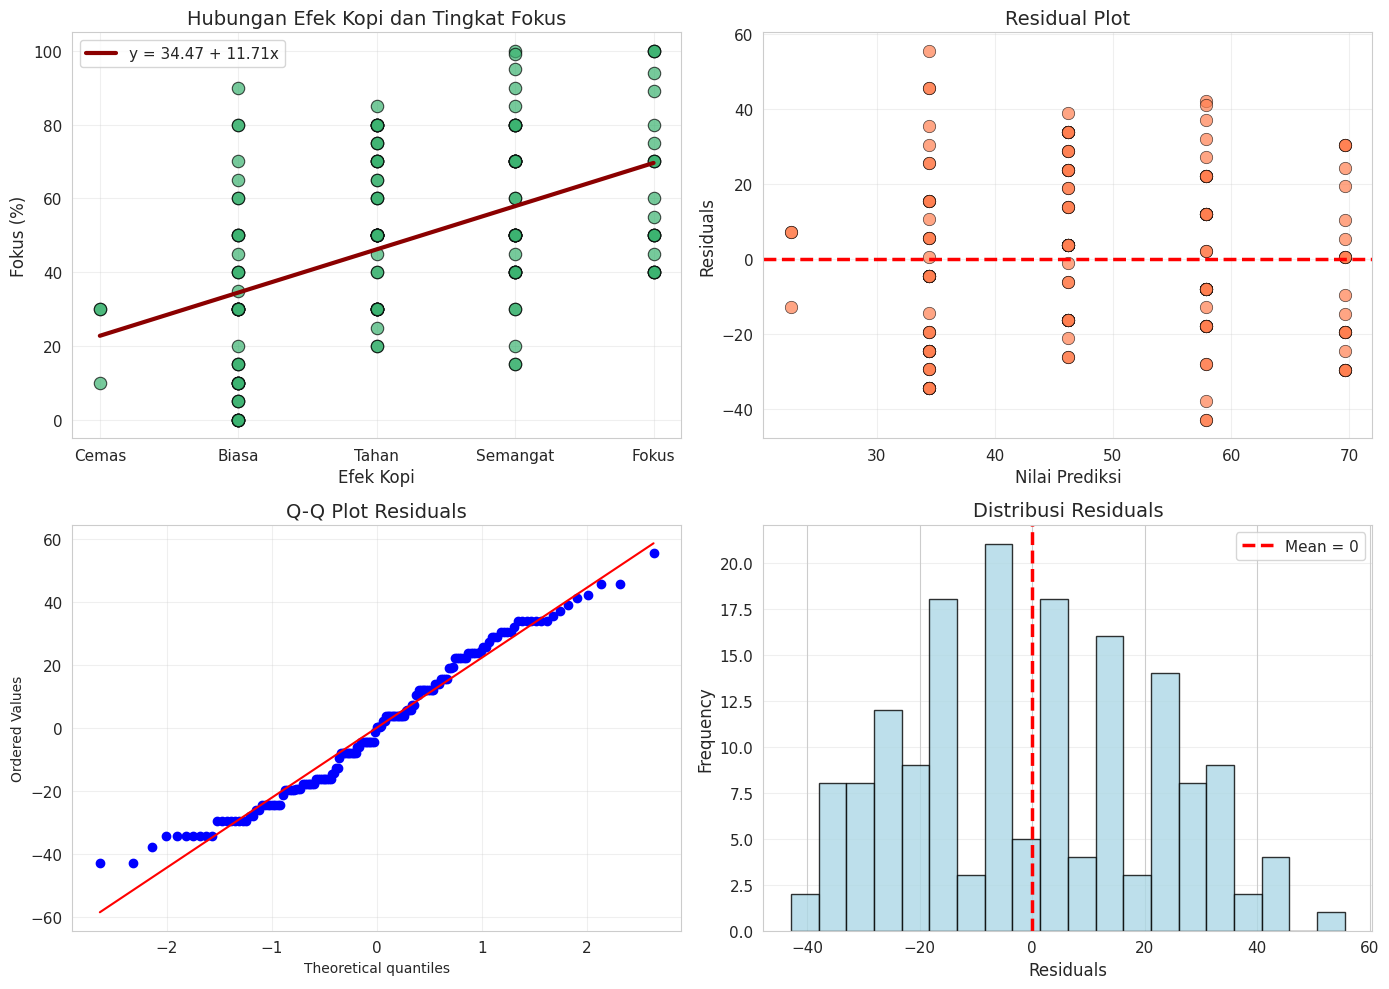

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot dengan garis regresi
axes[0,0].scatter(X, y, alpha=0.7, s=80, color='mediumseagreen', edgecolors='black', linewidth=0.8)
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
axes[0,0].plot(x_line, y_line, 'darkred', linewidth=3, label=f'y = {intercept:.2f} + {slope:.2f}x')
axes[0,0].set_xlabel('Efek Kopi', fontsize=12)
axes[0,0].set_ylabel('Fokus (%)', fontsize=12)
axes[0,0].set_title('Hubungan Efek Kopi dan Tingkat Fokus', fontsize=14)
axes[0,0].set_xticks([-1, 0, 1, 2, 3])
axes[0,0].set_xticklabels(['Cemas', 'Biasa', 'Tahan', 'Semangat', 'Fokus'], fontsize=11)
axes[0,0].tick_params(axis='y', labelsize=11)
axes[0,0].grid(alpha=0.3)
axes[0,0].legend(fontsize=11)

# Residual plot
axes[0,1].scatter(y_pred, residuals, alpha=0.7, s=80, color='coral', edgecolors='black', linewidth=0.5)
axes[0,1].axhline(y=0, color='red', linestyle='--', linewidth=2.5)
axes[0,1].set_xlabel('Nilai Prediksi', fontsize=12)
axes[0,1].set_ylabel('Residuals', fontsize=12)
axes[0,1].set_title('Residual Plot', fontsize=14)
axes[0,1].tick_params(axis='both', labelsize=11)
axes[0,1].grid(alpha=0.3)

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot Residuals', fontsize=14)
axes[1,0].tick_params(axis='both', labelsize=11)
axes[1,0].grid(alpha=0.3)

# Histogram residuals
axes[1,1].hist(residuals, bins=20, color='lightblue', edgecolor='black', alpha=0.8)
axes[1,1].axvline(x=0, color='red', linestyle='--', linewidth=2.5, label='Mean = 0')
axes[1,1].set_xlabel('Residuals', fontsize=12)
axes[1,1].set_ylabel('Frequency', fontsize=12)
axes[1,1].set_title('Distribusi Residuals', fontsize=14)
axes[1,1].tick_params(axis='both', labelsize=11)
axes[1,1].legend(fontsize=11)
axes[1,1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Scatter plot efek kopi dan tingkat fokus belajar menunjukkan garis regresi yang miring ke atas menunjukkan bahwa semakin besar efek kopi yang dirasakan, semakin tinggi pula tingkat fokus mahasiswa. Persamaan regresinya
34.47 + 11.71 𝑥 y=34.47+11.71x berarti setiap peningkatan satu tingkat efek kopi diikuti kenaikan fokus sekitar 11,7%.

Residual plot memperlihatkan titik-titik yang tersebar acak di sekitar garis nol, tanpa membentuk pola tertentu. Hal ini menunjukkan bahwa asumsi linearitas terpenuhi dan model regresi tidak memiliki masalah heteroskedastisitas yang berarti.

Q-Q plot memperlihatkan bahwa sebagian besar titik mengikuti garis diagonal merah. Pola ini menunjukkan bahwa residual berdistribusi mendekati normal, sehingga model regresi dapat dianggap valid secara statistik.

Histogram residual menampilkan bentuk yang hampir simetris dengan rata-rata di sekitar nol. Pola ini menandakan bahwa kesalahan prediksi tersebar seimbang, memperkuat kesimpulan bahwa model regresi sudah cukup baik dalam menggambarkan hubungan antara efek kopi dan fokus belajar.

## **Ringkasan Data Akhir**

In [44]:
summary_columns = [
    'timestamp', 'nama', 'npm', 'fakultas', 'prodi',
    'cara_dapat_kopi', 'waktu_ngopi', 'efek_kopi',
    'tempat_favorit', 'makna_ngopi',
    'gelas_num', 'pengeluaran_num', 'durasi_num',
    'frekuensi_cafe_num', 'fokus_num',
    'kat_pengeluaran', 'kat_fokus', 'kat_durasi'
]

ringkasan_data = df[summary_columns].copy()

print("Contoh Data Akhir Setelah EDA:")
display(ringkasan_data.head())

Contoh Data Akhir Setelah EDA:


,timestamp,nama,npm,fakultas,prodi,cara_dapat_kopi,waktu_ngopi,efek_kopi,tempat_favorit,makna_ngopi,gelas_num,pengeluaran_num,durasi_num,frekuensi_cafe_num,fokus_num,kat_pengeluaran,kat_fokus,kat_durasi
0,9/11/2025 14:20:36,R. Syailindra Alfarraiel,24083010030,Fakultas Ilmu Komputer,Sains Data,Beli kemasan siap minum,Sebelum berangkat kuliah,Tahan ngantuk,Cafe/warkop,Sekedar kebiasaan,1.0,10000.0,3.0,3,60.0,< Rp 15rb,Tinggi (51-70%),3-4 jam
1,9/11/2025 14:21:21,Farrel,24041010274,Fakultas Ilmu Sosial dan Ilmu Politik,Administrasi Publik,Bikin sendiri di rumah/kos,Setelah kuliah,Biasa aja,Rumah/kos,Sekedar kebiasaan,2.0,0.0,2.0,0,0.0,Tidak mengeluarkan,Tidak membantu,1-2 jam
2,9/11/2025 14:29:00,Farivatus Amalia,24041010218,Fakultas Ilmu Sosial dan Ilmu Politik,Administrasi Publik,Beli di cafe/warung kopi,Saat mengerjakan tugas,Lebih semangat,Cafe/warkop,Sekedar kebiasaan,1.0,100000.0,4.0,4,100.0,≥ Rp 100rb,Sangat Tinggi (>70%),3-4 jam
3,9/11/2025 14:31:32,Azzahra,23081010157,Fakultas Ilmu Komputer,Informatika,Beli di cafe/warung kopi,Saat mengerjakan tugas,Tahan ngantuk,Cafe/warkop,Kebutuhan wajib menemani mengerjakan tugas,1.0,30000.0,3.0,1,50.0,Rp 30-50rb,Sedang (31-50%),3-4 jam
4,9/11/2025 14:47:39,Hizkia Samhan Rezayoshi,24083010019,Fakultas Ilmu Komputer,Sains Data,Beli di cafe/warung kopi,Saat mengerjakan tugas,Biasa aja,Rumah/kos,Kebutuhan wajib menemani mengerjakan tugas,1.0,15000.0,4.0,1,40.0,Rp 15-30rb,Sedang (31-50%),3-4 jam


In [45]:
print("Distribusi Kategori Pengeluaran:")
print(ringkasan_data['kat_pengeluaran'].value_counts())

Distribusi Kategori Pengeluaran:
kat_pengeluaran
< Rp 15rb             58
Rp 15-30rb            48
Rp 30-50rb            20
Rp 50-100rb           18
Tidak mengeluarkan    11
≥ Rp 100rb            10
Name: count, dtype: int64


In [46]:
print("Distribusi Kategori Fokus:")
print(ringkasan_data['kat_fokus'].value_counts())

Distribusi Kategori Fokus:
kat_fokus
Sedang (31-50%)         53
Rendah (1-30%)          43
Sangat Tinggi (>70%)    32
Tinggi (51-70%)         30
Tidak membantu           7
Name: count, dtype: int64


In [47]:
print("Distribusi Kategori Durasi:")
print(ringkasan_data['kat_durasi'].value_counts())

Distribusi Kategori Durasi:
kat_durasi
3-4 jam              71
5-6 jam              34
1-2 jam              33
Tidak berpengaruh    17
> 6 jam              10
Name: count, dtype: int64
